[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

# 투빅스 25&26기 2주차 2교시 — Deep Learning 과제 [sklearn `digits` 손글씨 분류]


## 과제 목적

이번 과제는 `sklearn`의 `digits` 데이터셋을 이용해 **MLP를 직접 학습**하고, DNN의 세 가지 고질병인 **Vanishing Gradient · Overfitting · Optimization**을 실제 실험 결과로 확인하는 프로젝트입니다. §1.1에서는 데이터를 확인하고 train / validation / test로 분리하며, §1.2에서는 PyTorch로 미니배치 SGD 학습 루프를 완성합니다. 이어지는 §1.3~1.5에서는 활성화 함수, 규제 방법, optimizer를 하나씩 바꾸며 강의의 설명이 실제 학습 곡선과 수치에서 어떻게 나타나는지 검증합니다. 마지막 심화(§2)에서는 "활성화 함수가 없으면 층을 쌓아도 선형모델"이라는 주장을 직접 확인하고, 파라미터 수를 맞춘 Wide vs Deep 비교를 통해 "Deep이 항상 더 좋은가"를 본인 실험으로 판단합니다.

## 주의 사항
각 코드 셀의 빈칸(`# TODO: ____`, `____`)을 채우며 **"지금 어느 단계에서 무엇을 하고 있는가"**를 확인하세요. 앞 단계에서 만든 변수와 함수가 뒤 절에서 계속 사용되므로 **맨 위 셀부터 순서대로** 실행해야 합니다.


## 제출물

1. 빈칸을 모두 채우고 **전부 실행한** 이 노트북 (출력 포함)
2. 기술블로그 '과제 복습' 섹션 — §1.3~1.5의 실험 결과 그래프와 본인 해석을 옮겨 정리


---

## 0. 환경 설정 — 라이브러리, 시드, 데이터 로드

이번 과제는 **별도 파일 업로드가 필요 없습니다.** scikit-learn에 내장된 **`load_digits()`** 를 씁니다.

- **무슨 데이터?** 손글씨 숫자 이미지 **1,797장**. 각 이미지는 **8×8 = 64 픽셀**, 픽셀 값은 **0~16**의 정수(밝기). 정답은 **0~9의 10개 클래스**입니다.
- **왜 이 데이터?** 강의의 마지막 슬라이드 구조(`Input -> Hidden -> Output`, `# of nodes: 변수 개수(d) / 자유 / Task에 의존`)를 그대로 적용할 수 있습니다. 입력 노드는 **64개(픽셀 수 = d)**, 출력 노드는 **10개(클래스 수 = Task에 의존)**, 은닉층은 **자유**입니다. 그리고 크기가 작아 Colab CPU에서도 실험 하나가 몇 초면 끝나므로, **여러 조건을 비교**하는 이번 과제에 적합합니다.

이 셀에서 하는 일은 세 가지입니다.

**1) 라이브러리 import.** 이후 모든 셀이 여기서 불러온 이름(`np`, `torch`, `nn` 등)을 씁니다. 한 번만 실행하면 됩니다.

**2) `MY_SEED` 설정.** *시드(seed)* 는 난수 생성기의 출발점입니다. 딥러닝에는 무작위가 **최소 세 군데** 들어갑니다 — ① **가중치 초기화**, ② **train/val/test 분할**, ③ **미니배치 셔플 순서**. 시드를 고정해야 재현이 되고 채점이 가능합니다.

**3) 데이터 로드.** `load_digits()`는 sklearn 패키지 안에 들어 있어 인터넷 없이도 즉시 로드됩니다.

> 시드를 고정한다고 결과가 **편향**되는 것은 아닙니다. 무작위 절차를 **재현 가능**하게 만들 뿐입니다.

In [1]:
!pip install torch

In [1]:
# ── 라이브러리 import (한 번만 실행; 이후 모든 셀이 이 이름을 그대로 사용) ──
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── 0. 환경 설정 ──────────────────────────────────────────────
# (1) 시드 설정 — 본인 학번 뒷 4자리를 넣으세요 (예: 2026-12345 → 2345)
MY_SEED = 9356             # TODO: 학번 뒷 4자리
np.random.seed(MY_SEED)       # TODO: NumPy 난수 고정
torch.manual_seed(MY_SEED)     # TODO: PyTorch 난수 고정 (가중치 초기화·셔플에 영향)

# (2) 데이터 로드 — sklearn 내장 데이터라 다운로드/업로드가 필요 없다
digits = load_digits()
X = digits.data          # (n_samples, 64)  픽셀 밝기 0~16
y = digits.target        # (n_samples,)     정답 클래스 0~9

# (3) 로드 확인
print("PyTorch version :", torch.__version__)
print("MY_SEED         :", MY_SEED)
print("X shape (샘플수, 픽셀수) :", X.shape)      # 기대: (1797, 64)
print("y shape                  :", y.shape)
print("클래스 종류              :", np.unique(y))
print("픽셀 값 범위             :", X.min(), "~", X.max())

PyTorch version : 2.6.0+cpu
MY_SEED         : 9356
X shape (샘플수, 픽셀수) : (1797, 64)
y shape                  : (1797,)
클래스 종류              : [0 1 2 3 4 5 6 7 8 9]
픽셀 값 범위             : 0.0 ~ 16.0


**Q0. 데이터를 제대로 불렀는지 확인해 봅시다.**

1. `X.shape`는 무엇인가요? **샘플 수**와 **픽셀 수**를 본인이 본 실제 숫자로 적으세요.
*-> `(1797, 64)`. 손글씨 이미지 1,797장이고, 각 장은 8×8 이미지를 한 줄로 편 64개 픽셀이다. 픽셀 값 범위는 0.0 ~ 16.0.*

2. 강의 마지막 NN Structure 표(p.28)에 따르면 **Input layer의 노드 수 = 변수 개수(d)**, **Output layer의 노드 수 = Task에 의존**입니다. 이 데이터에서 입력 노드 수와 출력 노드 수는 각각 몇 개여야 하나요? 그 근거를 위 출력값으로 대세요.
*-> 입력 64개, 출력 10개. 입력은 `X.shape`의 두 번째 축이 곧 변수 개수 d = 64이기 때문이고, 출력은 `np.unique(y)`가 `[0 1 2 3 4 5 6 7 8 9]`로 클래스가 10개라 클래스마다 점수 하나씩 필요하기 때문이다. 이 둘은 데이터와 과제가 강제하는 값이고, 자유롭게 고를 수 있는 것은 은닉층뿐이다.*

3. `MY_SEED`를 다른 값으로 바꿔 이 셀을 다시 실행하면 `X.shape`가 달라질까요? 한 줄로 설명하세요.
*-> 달라지지 않는다. `load_digits()`는 패키지에 저장된 배열을 그대로 읽어올 뿐이고, 시드가 바꾸는 것은 `train_test_split`의 분할, 가중치 초기값, 미니배치 셔플 순서뿐이다.*

> 힌트(3번): 시드는 *무작위 절차*(초기화·셔플·분할)에만 영향을 줍니다. 패키지에 들어 있는 데이터를 그대로 읽어오는 것은 무작위가 아닙니다.

---

# 1. 필수 과제

아래 1.1~1.5를 **순서대로** 완성합니다. 앞 단계에서 만든 변수(`X_train_s`, `train_model` 등)를 뒤 단계가 그대로 쓰므로 **위에서부터 차례로** 실행하세요.

흐름은 다음과 같습니다.

```
1.1 데이터 준비  ->  1.2 PyTorch MLP 학습 (미니배치 SGD 루프)
                             ↓
          1.3 Vanishing Gradient  /  1.4 Overfitting  /  1.5 Optimization
             (강의 4장 "Critical Issues & Remedies"를 각각 실험으로 확인)
```

---

### 1.1 데이터 만나기 — 이미지 확인과 train / val / test 분리

먼저 데이터를 **눈으로** 봅니다. 8×8 배열을 이미지로 그려 "이게 정말 손글씨 숫자인가"를 확인하고, 클래스가 한쪽으로 쏠려 있지는 않은지 셉니다.

그다음 데이터를 **세 덩어리**로 나눕니다. 1주차에서는 train/test 둘로만 나눴지만, 딥러닝에서는 **validation(검증) 세트가 하나 더** 필요합니다.

| 세트 | 쓰는 곳 | 강의 연결 |
|---|---|---|
| **train** | 가중치를 학습(업데이트)하는 데이터 | 4장 Remedy ①: 미니배치 SGD가 도는 곳 |
| **validation** | **학습 중** 성능을 감시하며 언제 멈출지·어떤 설정이 나은지 고르는 데이터 | 4장 Issue 2 Remedy ①: Early Stopping의 판단 기준 |
| **test** | **마지막에 딱 한 번** 최종 성능을 재는 데이터 | 일반화(Generalization) 성능의 최종 보고 |

**Early Stopping은 val loss를 보고 멈추는 방법**입니다(강의 p.40). 그런데 만약 test로 멈출 시점을 고르면, test는 더 이상 "본 적 없는 데이터"가 아니게 되어 성능이 부풀려집니다 — 이것이 **데이터 누수(data leakage)** 입니다. 그래서 세 덩어리가 필요합니다.

**표준화(StandardScaler)** 도 같은 이유로 조심해야 합니다. 각 픽셀을 평균 0·표준편차 1로 맞추면 학습이 훨씬 안정적인데(값의 스케일이 제각각이면 gradient도 제각각), **평균과 표준편차는 반드시 train에서만 계산(`fit`)** 하고 val/test에는 그 값을 **적용(`transform`)** 만 해야 합니다. test의 평균까지 써서 스케일링하면 test 정보가 학습 과정에 새어 들어갑니다.

> ⚠️ 참고: `digits`에는 항상 0인 픽셀(테두리)이 있어 표준편차가 0인 열이 생깁니다. sklearn은 이런 열을 0으로 나누지 않고 그대로 두므로 에러는 나지 않습니다.


클래스별 샘플 수: [178 182 177 183 181 182 181 179 174 180]
가장 많은 클래스 / 가장 적은 클래스: 183 / 174


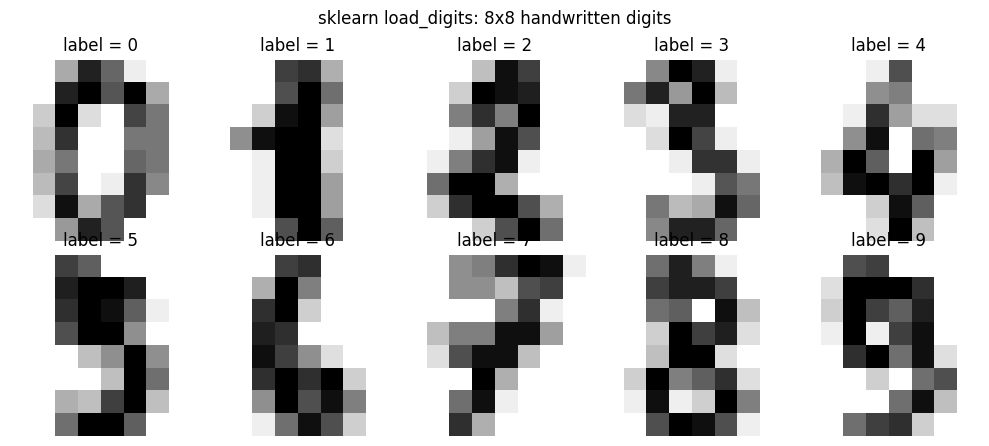


분할 결과  train: (1078, 64)  val: (359, 64)  test: (360, 64)
표준화 후 train 평균/표준편차 (전체 픽셀 기준): -0.0000 / 0.9682
표준화 후 test  평균/표준편차 (전체 픽셀 기준): 0.0039 / 0.9622   <- 정확히 0/1이 아닌 것이 정상

텐서 변환 완료: torch.Size([1078, 64]) torch.Size([1078]) torch.int64


In [2]:
# ── 1.1 데이터 확인 & 분할 ─────────────────────────────────────

# (1) 클래스별 개수 세기 — 한쪽으로 쏠려 있는가?
print("클래스별 샘플 수:", np.bincount(y))     # TODO: 정답 배열을 넣어 클래스별 개수를 센다
print("가장 많은 클래스 / 가장 적은 클래스:", np.bincount(y).max(), "/", np.bincount(y).min())

# (2) 이미지 10장 눈으로 확인 (보일러플레이트 — 그대로 두세요)
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap="gray_r")
    ax.set_title(f"label = {y[i]}")
    ax.axis("off")
plt.suptitle("sklearn load_digits: 8x8 handwritten digits")
plt.tight_layout()
plt.show()

# (3) train : val : test = 60 : 20 : 20 으로 두 번에 걸쳐 분할
#     stratify=... 를 주면 각 세트의 클래스 비율이 원본과 같게 유지된다.
# TODO: 먼저 전체를 train(60%) / 임시(40%)로 나눈다. random_state 는 MY_SEED.
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size= 0.4, random_state= MY_SEED, stratify= y
)
# TODO: 임시(40%)를 다시 반으로 갈라 val(20%) / test(20%)로 만든다.
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=MY_SEED, stratify=y_tmp
)
print("\n분할 결과  train:", X_train.shape, " val:", X_val.shape, " test:", X_test.shape)

# (4) 표준화 — 평균/표준편차는 반드시 train 에서만 학습(fit)한다!
scaler = StandardScaler()
# TODO: train 에만 fit 하고, 세 세트 모두 transform 한다. (fit_transform 을 val/test 에 쓰면 누수!)
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("표준화 후 train 평균/표준편차 (전체 픽셀 기준): "
      f"{X_train_s.mean():.4f} / {X_train_s.std():.4f}")
print("표준화 후 test  평균/표준편차 (전체 픽셀 기준): "
      f"{X_test_s.mean():.4f} / {X_test_s.std():.4f}   <- 정확히 0/1이 아닌 것이 정상")

# (5) PyTorch 텐서로 변환 (실수형 X, 정수형 라벨 y)
Xtr = torch.tensor(X_train_s, dtype=torch.float32); ytr = torch.tensor(y_train, dtype=torch.long)
Xva = torch.tensor(X_val_s,   dtype=torch.float32); yva = torch.tensor(y_val,   dtype=torch.long)
Xte = torch.tensor(X_test_s,  dtype=torch.float32); yte = torch.tensor(y_test,  dtype=torch.long)
print("\n텐서 변환 완료:", Xtr.shape, ytr.shape, ytr.dtype)

**해석 질문 1.1 (본인이 출력한 실제 값을 인용해 답하세요)**

1. train / val / test 각각 몇 개의 샘플이 배정되었나요? 클래스별 개수(`np.bincount(y)`)를 보고, 이 데이터가 1주차 Framingham의 `TenYearCHD`(양성 약 15%)처럼 **불균형**한지 아닌지 판단하세요. 불균형하지 않다면, "무조건 한 클래스로만 찍는" 모델의 정확도는 몇 % 정도일까요?
*-> train 1,078 / val 359 / test 360으로 60:20:20이 그대로 지켜졌다. 클래스별 개수는 최소 174, 최대 183으로 비율이 0.95:1이라 사실상 균등하다. 한 클래스로만 찍는 모델의 정확도는 최빈 클래스 비율인 183/1797 = 10.18%(test 기준 37/360 = 10.28%)에 그친다. 즉 이 과제에서 정확도 10%는 "아무것도 학습하지 않은 상태"를 뜻하는 하한선이고, 뒤에 나오는 §1.3 Sigmoid의 0.1985나 §1.5 `SGD lr=3.0`의 0.1003을 읽을 때 이 기준선과 비교해야 한다.*

2. `X_test_s`의 평균이 정확히 0이 **아닌** 이유는 무엇인가요? 만약 `scaler.fit_transform(X_test)` 로 test에도 따로 fit 했다면 평균은 0이 되었을 텐데, 그렇게 하면 **왜 안 되는지** '데이터 누수' 개념으로 설명하세요.
*-> test를 변환할 때 쓴 평균·표준편차가 test 자신의 것이 아니라 train에서 계산한 값이기 때문이다. train 평균은 -0.0000인데 test 평균이 0.0039, 표준편차가 0.9622인 것은 두 표본의 분포가 미세하게 다르다는 뜻이고, 이 어긋남 자체가 "test 정보를 쓰지 않았다"는 증거다. test에 따로 `fit`하면 평균은 0이 되지만 그 순간 test의 통계량이 전처리에 반영되어 test는 더 이상 본 적 없는 데이터가 아니게 된다. 애초에 실전에서는 예측 시점에 test 전체를 모아 평균을 낼 수 없으므로, 그렇게 잰 성능은 배포 환경에서 재현되지 않는 숫자다.*

3. train / val / test **세 덩어리**가 필요한 이유를, 강의 p.40 **Early Stopping**과 연결해 한 문장으로 쓰세요. (힌트: 멈출 시점을 무엇으로 고르고, 최종 성적표는 무엇으로 매기는가?)
*-> 가중치는 train으로 학습하고 언제 멈출지는 val로 고르되, 선택에 쓴 데이터로 점수를 매기면 일반화 성능이 아니라 그 데이터에 맞춘 성능이 되므로 최종 점수는 선택에 관여하지 않은 test로만 매겨야 하기 때문이다.*

---

### 1.2 PyTorch로 MLP 학습하기 — 미니배치 SGD 루프를 직접 채우기

§1.1에서 준비한 데이터를 이용해 이제 **PyTorch MLP를 직접 학습**합니다. 모델과 손실 함수는 PyTorch가 제공하지만, 강의 p.47의 **미니배치 SGD 4단계**는 직접 코드로 완성합니다.

> **Loop:**
> 1. **미니배치 샘플링** — 전체 학습 데이터에서 일부를 미니배치로 추출
> 2. **순전파 및 손실 계산** — 미니배치를 모델에 입력하여 예측값과 손실을 계산
> 3. **역전파** — 손실을 기준으로 각 파라미터의 기울기를 계산
> 4. **파라미터 업데이트** — 계산된 기울기의 반대 방향으로 파라미터를 업데이트

이 네 단계는 PyTorch 코드와 거의 그대로 대응됩니다.

| 강의 단계 | PyTorch 코드 |
|---|---|
| 1. 미니배치 샘플링 | `for xb, yb in loader:` (DataLoader가 대신 수행) |
| 2. 순전파 + 손실 | `loss = criterion(model(xb), yb)` |
| 3. 역전파 | `loss.backward()` |
| 4. 업데이트 | `optimizer.step()` |
| (+) 기울기 초기화 | `optimizer.zero_grad()` <- **매 스텝 맨 앞에!** |

⚠️ **`optimizer.zero_grad()`를 빠뜨리면** PyTorch는 gradient를 덮어쓰지 않고 **누적**합니다. 이전 미니배치의 기울기가 계속 더해져 학습이 의도와 다르게 진행되므로, 순서(`zero_grad -> forward/loss -> backward -> step`)를 기억하세요.

**`nn.CrossEntropyLoss`의 주의점** — 이 함수는 내부에서 softmax와 cross entropy 계산을 함께 처리합니다. 따라서 모델의 마지막 층은 **`nn.Linear`로 끝내고 softmax를 따로 붙이지 않습니다.** softmax를 추가하면 같은 변환이 중복되어 학습 성능이 나빠질 수 있습니다.

**`model.train()` / `model.eval()`** — Dropout(§1.4)처럼 학습할 때와 평가할 때 **동작이 달라지는 층**이 있으므로 모드를 명시해야 합니다. `torch.no_grad()`는 평가 중 gradient 계산 그래프를 만들지 않아 메모리 사용량과 계산량을 줄입니다.

**이번 절의 모델 (강의 p.28 표대로):** `Input 64` -> `Hidden 64 (ReLU)` -> `Hidden 32 (ReLU)` -> `Output 10`


In [3]:
# ── 1.2 공용 도구: 모델 빌더 · 평가 함수 · 학습 루프 ────────────
# 여기서 만든 세 함수는 §1.3 ~ §2 에서 계속 재사용합니다.

criterion = nn.CrossEntropyLoss()   # softmax 를 내부에 포함! 모델 끝에 softmax 붙이지 말 것

def build_mlp(hidden=(64, 32), act=nn.ReLU, in_dim=64, out_dim=10, p_drop=0.0, seed=MY_SEED):
    """(입력) -> [Linear -> act -> (Dropout)] x len(hidden) -> Linear(출력) 구조의 MLP."""
    torch.manual_seed(seed)          # 초기화 재현성
    layers, prev = [], in_dim
    for hdim in hidden:
        # TODO: Linear(prev -> hdim) 과 활성화 함수 act() 를 차례로 추가하라
        layers += [nn.Linear(prev,hdim), act()]
        if p_drop > 0:
            layers.append(nn.Dropout(p_drop))
        prev = hdim
    # TODO: 마지막 출력층 (활성화 함수 없이 Linear 로 끝낸다 — CrossEntropyLoss 가 softmax 담당)
    layers.append(nn.Linear(prev,out_dim))
    return nn.Sequential(*layers)

@torch.no_grad()                     # 평가 중에는 gradient 를 만들지 않는다
def evaluate(model, X, y):
    """(loss, accuracy) 를 돌려준다."""
    # TODO: 평가 모드로 전환 (Dropout 등을 끈다)
    model.eval()
    out = model(X)
    loss = criterion(out, y).item()
    # TODO: 가장 확률이 큰 클래스를 예측으로 삼아 정확도를 구하라 (힌트: out.argmax(1))
    acc = (out.argmax(1) == y).float().mean().item()
    return loss, acc

def train_model(model, Xt=Xtr, yt=ytr, Xv=Xva, yv=yva, epochs=60,
                opt_name="adam", lr=1e-3, weight_decay=0.0, batch_size=64, seed=MY_SEED):
    """미니배치 SGD 루프. epoch 마다 train/val 의 loss·accuracy 를 기록해 돌려준다."""
    torch.manual_seed(seed)

    # ── optimizer 선택 (§1.5 에서 이 세 가지를 비교합니다) ──
    if opt_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "momentum":
        # TODO: SGD 에 momentum=0.9 를 주어 강의 p.48 의 Momentum 을 만든다
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum= 0.9, weight_decay=weight_decay)
    elif opt_name == "adam":
        # TODO: Adam optimizer 를 만든다 (lr, weight_decay 전달)
        optimizer = torch.optim.Adam(model.parameters(), lr = lr, weight_decay=weight_decay)
    else:
        raise ValueError(opt_name)

    g = torch.Generator().manual_seed(seed)          # 셔플 순서 재현
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True, generator=g)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(epochs):
        model.train()                                 # 학습 모드
        for xb, yb in loader:                         # [단계1] 미니배치 샘플링
            # TODO [+] 이전 스텝의 gradient 를 0으로 초기화
            optimizer.zero_grad()
            # TODO [단계2] 순전파 + 손실 계산
            loss = criterion(model(xb), yb)
            # TODO [단계3] 역전파 — 각 파라미터의 gradient 계산
            loss.backward()
            # TODO [단계4] gradient 반대 방향으로 파라미터 업데이트
            optimizer.step()

        tl, ta = evaluate(model, Xt, yt)
        vl, va = evaluate(model, Xv, yv)
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_acc"].append(ta);  hist["val_acc"].append(va)
    return hist

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def plot_curves(hist_dict, title, metric="loss"):
    """{이름: hist} 를 받아 train(점선)/val(실선) 곡선을 겹쳐 그린다."""
    plt.figure(figsize=(7, 4.2))
    for name, h in hist_dict.items():
        line, = plt.plot(h[f"val_{metric}"], label=f"{name} (val)")
        plt.plot(h[f"train_{metric}"], linestyle="--", alpha=0.6,
                 color=line.get_color(), label=f"{name} (train)")
    plt.xlabel("epoch"); plt.ylabel(metric); plt.title(title)
    plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("도구 준비 완료:", build_mlp, evaluate, train_model, sep="\n  ")

도구 준비 완료:
  <function build_mlp at 0x00000236EBD671A0>
  <function evaluate at 0x00000236E9AD0FE0>
  <function train_model at 0x00000236E9AD1580>


Sequential(
  (0): Linear(in_features=64, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=10, bias=True)
)
파라미터 수: 6570


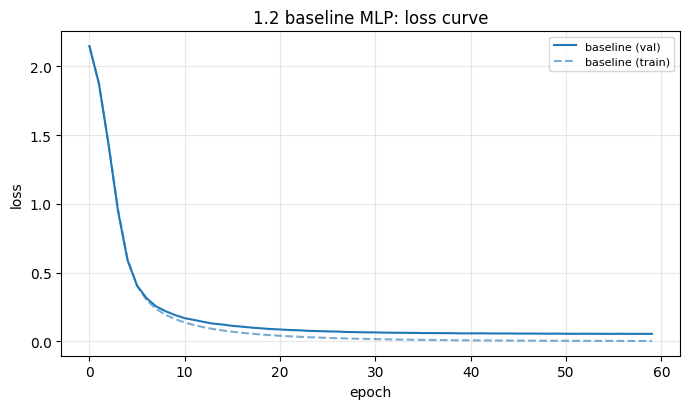

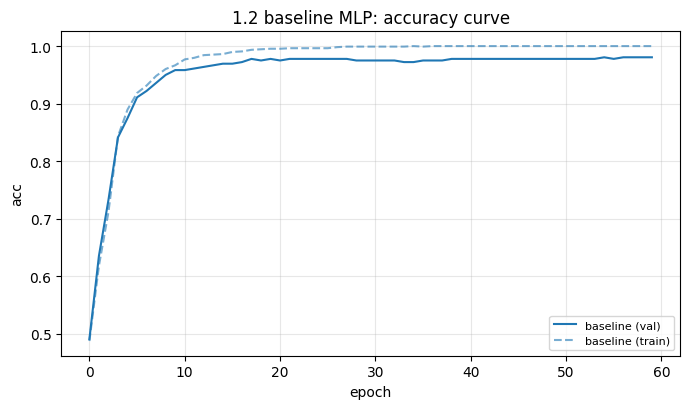


[최종] test loss = 0.1227 | test accuracy = 0.9694
val_loss 최저 epoch = 59 (val_loss = 0.0547)
마지막 epoch 의 train_loss = 0.0031 / val_loss = 0.0547
train_acc = 1.0000 / val_acc = 0.9805


In [4]:
# ── 1.2 baseline MLP 학습: 64 -> 64 -> 32 -> 10 ────────────────
baseline = build_mlp(hidden=(64, 32), act=nn.ReLU)
print(baseline)
print("파라미터 수:", count_params(baseline))

hist_base = train_model(baseline, epochs=60, opt_name="adam", lr=1e-3)

# 학습 곡선 (강의 p.40 Early Stopping 그림과 같은 형태가 나오는지 보세요)
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: loss curve", metric="loss")
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: accuracy curve", metric="acc")

# TODO: 마지막에 딱 한 번, test 세트로 최종 성능을 측정하라
test_loss, test_acc = evaluate(baseline, Xte, yte)
print(f"\n[최종] test loss = {test_loss:.4f} | test accuracy = {test_acc:.4f}")

# TODO: val_loss 가 가장 낮았던 epoch 번호를 찾아라 (Early Stopping 이라면 여기서 멈췄을 것)
best_ep = int(np.argmin(hist_base['val_loss'])) + 1
print(f"val_loss 최저 epoch = {best_ep} (val_loss = {min(hist_base['val_loss']):.4f})")
print(f"마지막 epoch 의 train_loss = {hist_base['train_loss'][-1]:.4f} / "
      f"val_loss = {hist_base['val_loss'][-1]:.4f}")
print(f"train_acc = {hist_base['train_acc'][-1]:.4f} / val_acc = {hist_base['val_acc'][-1]:.4f}")

**해석 질문 1.2 (본인 출력값 인용)**

1. 이 모델의 **파라미터 수**는 몇 개인가요? 손으로도 계산해 확인하세요: $64{\times}64+64$, $64{\times}32+32$, $32{\times}10+10$ 의 합과 같은가요? (bias를 빠뜨리지 마세요.)
*-> 6,570개로 정확히 일치한다. 4160 + 2080 + 330 = 6570이고, 이 중 bias가 64 + 32 + 10 = 106개다. 여기서 은닉층끼리 맞닿은 구간(64×32)만 폭을 키울 때 두 축이 함께 커진다. 은닉층이 하나뿐인 Wide는 입출력 차원이 64와 10으로 고정되어 파라미터가 75H + 10으로 폭에 비례하지만, 은닉층 4개를 h로 쌓은 Deep은 h×h 연결이 세 번 생겨 3h² + 78h + 10으로 제곱에 비례한다.*

2. 본인의 **test accuracy**를 적으세요. §1.1에서 계산한 "무조건 한 클래스로 찍기" 정확도와 비교하면 얼마나 나은가요?
*-> test accuracy 0.9694 (test loss 0.1227). 한 클래스로만 찍는 10.18%의 9.5배이고, 오답률로 보면 89.8%에서 3.06%로 줄었다. test 360장 중 11장을 틀린 셈이다.*

3. **loss 곡선을 보세요.** train loss는 계속 내려가는데 val loss는 어느 지점부터 더 내려가지 않거나 **살짝 올라가기 시작**했을 것입니다. 그 지점(대략 몇 epoch)과, 그때 train/val loss 값을 적으세요. 이 그림이 강의 p.40 Early Stopping 슬라이드의 그림과 어떻게 대응되는지 설명하세요.
*-> 이 설정에서는 val loss가 끝까지 반등하지 않았다. 최저는 마지막 직전인 epoch 59(val_loss 0.0547)였고 마지막 epoch 60도 0.0547로 소수 넷째 자리까지 같다. 이때 train_loss는 0.0031, train_acc는 1.0000, val_acc는 0.9805다. train_acc가 1.0에 도달한 뒤에도 val_loss가 계속 완만히 내려갔다는 것은, 모델이 훈련셋을 다 외운 뒤에도 예측의 확신도를 옳은 방향으로 더 다듬고 있었다는 뜻이다. 즉 이 곡선은 강의 Early Stopping 슬라이드에서 train과 val이 함께 내려가는 앞 구간에 해당하고, val loss가 꺾여 올라가 멈춰야 할 이유가 생기는 뒤 구간은 아직 오지 않았다. Early Stopping이 발동할 근거가 없는 상태이며, 훈련 데이터를 150개로 줄인 §1.4에서 비로소 그 뒤 구간(baseline이 epoch 32에서 최저를 찍고 반등)이 나타난다. 데이터가 1,078개로 충분해 과적합 압력이 약했던 것이 원인이다.*

4. `optimizer.zero_grad()` 를 **일부러 지우고** 다시 실행해 보세요(다른 셀에 복사해서 실험할 것). 학습 곡선이 어떻게 달라졌나요? PyTorch가 gradient를 **누적**한다는 사실과 연결해 설명하세요.
*-> 같은 시드·같은 설정에서 `zero_grad()`만 빼고 60 epoch를 돌린 결과, test accuracy는 0.9694 -> 0.9222, 최종 val_loss는 0.0547 -> 1.4254로 26배 나빠졌다. 그런데 초반 5 epoch의 val_acc는 0.5070 / 0.6490 / 0.6880 / 0.8412 / 0.8412로 정상 학습(0.4903 / 0.6351 / 0.7326 / 0.8412 / 0.8747)과 거의 같다. `.grad`가 한 번도 초기화되지 않으면 그 값은 지금 미니배치의 기울기가 아니라 학습을 시작한 이래 모든 배치 기울기의 합이 된다. 초반에는 배치들이 대체로 같은 방향을 가리켜 합의 방향이 유지되지만, 후반의 미세조정 단계에서는 이미 지나간 배치의 낡은 기울기가 계속 섞여 들어와 세밀한 수정을 막는다. 그래도 완전히 무너지지 않은 것은 optimizer가 Adam이기 때문이다. Adam은 스텝을 m/sqrt(v)로 정규화해 기울기가 몇 배 커져도 이동 거리가 거의 변하지 않는다. `SGD lr=0.05`로 바꿔 같은 실험을 하면(20 epoch) 정상은 train_loss 0.1936 / val_acc 0.9526인데 누적 버전은 train_loss가 1.7931에서 2.8475로 커지며 val_acc 0.1170으로 붕괴한다. 원인은 하나지만 증상의 크기는 optimizer가 정한다.*

5. 모델 마지막에 `nn.Softmax(dim=1)` 을 추가하면 어떻게 될지 예상하고, 실제로 추가해 성능을 비교해 보세요. (힌트: `nn.CrossEntropyLoss`는 이미 softmax를 품고 있습니다.)
*-> 예상: `CrossEntropyLoss`가 내부에서 log_softmax를 적용하므로 softmax가 두 번 걸리고, 정답 확률의 상한이 낮아져 loss가 바닥에 갇히고 학습이 느려진다. 실측(같은 시드, 60 epoch): test accuracy 0.9694 -> 0.9639, 최종 train_loss 0.0031 -> 1.4664, train_acc 0.99 도달이 17 epoch -> 25 epoch, epoch 5의 val_acc가 0.8747 -> 0.7437로 느려졌다. 여기서 1.4664라는 값이 결정적이다. 첫 softmax의 출력은 [0, 1] 범위로 눌리므로 두 번째 softmax가 받는 logit의 최대 격차가 1이고, 모델이 완벽하게 맞혀 확률벡터가 [1, 0, ..., 0]이 되어도 최종 정답 확률은 e/(e+9) = 0.2320이 상한이다. 따라서 달성 가능한 최소 loss가 −ln(0.2320) = 1.4612이고, 실측 1.4664는 이 하한에 거의 붙어 있다. 즉 남은 loss는 모델이 덜 배워서가 아니라 구조가 만든 바닥이며, 더 학습해도 내려갈 곳이 없다. 정확도가 크게 무너지지 않는 이유는 softmax가 순서를 보존하는 단조 변환이라 argmax가 대체로 유지되기 때문이지만, 확률값의 해석과 최적화 신호는 이미 망가진 상태다.*

---

### 1.3 Issue 1) Vanishing Gradient — 강의의 주장을 gradient로 직접 재기

강의 4장은 "Deep architecture는 input에서 output까지 gradient chain이 길어서 **Vanishing Gradient**가 생기고, 처방은 **non-saturating 활성화 함수(ReLU 계열)**"라고 말합니다(p.37~38). 여기서는 그 말을 **숫자로 확인**합니다.

**실험 설계**

- 은닉층 **8개**(width 32)를 쌓은 깊은 MLP를 두 개 만듭니다. **딱 하나만 다릅니다: 활성화 함수가 Sigmoid냐 ReLU냐.**
- 아직 **학습은 하지 않고**, 초기 파라미터에서 **역전파를 딱 한 번** 돌립니다.
- 그리고 **각 층 가중치의 gradient 크기(L2 norm)** 를 재서, 출력층에서 입력층으로 갈수록 얼마나 작아지는지 봅니다.
- 마지막으로 두 네트워크를 실제로 40 epoch 학습시켜 **성능 차이**를 확인합니다.

**왜 gradient의 norm인가?** gradient가 0에 가깝다는 것은 "이 층의 가중치를 아무리 바꿔도 loss가 거의 안 변한다 -> **업데이트 신호가 없다 -> 학습이 안 된다**"는 뜻입니다. Sigmoid를 한 번 지날 때마다 도함수 $h(1-h) \le 0.25$가 곱해지므로, 층이 깊어질수록 앞쪽 층의 gradient는 기하급수적으로 줄어듭니다.

> 📌 **이 절의 결과가 강의 마지막 서술형 퀴즈의 답입니다.** 그래프를 캡처해 기술블로그에 넣고, "chain rule 관점에서 왜 사라지는가"를 본인 숫자로 설명하세요.

층 번호 1 = 입력에 가장 가까운 층,  마지막 = 출력층

[Sigmoid]  1.65e-07 3.61e-07 2.42e-06 1.92e-05 1.43e-04 1.08e-03 6.72e-03 4.48e-02 2.90e-01
[ReLU]     4.52e-04 4.09e-04 5.41e-04 4.91e-04 4.81e-04 7.93e-04 1.20e-03 3.64e-03 1.28e-02

Sigmoid: 마지막층 / 첫번째층 = 1.758e+06 배
ReLU   : 마지막층 / 첫번째층 = 2.830e+01 배


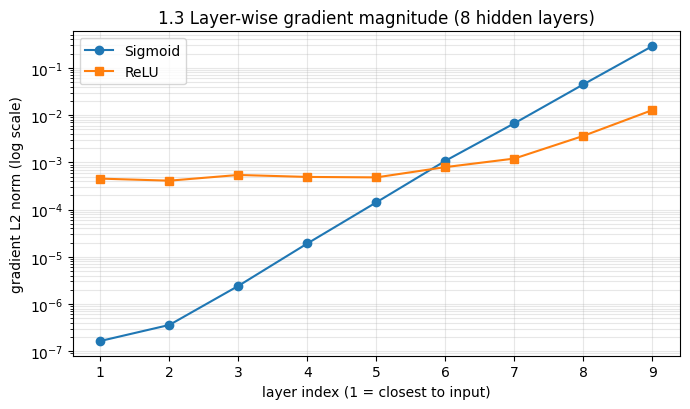

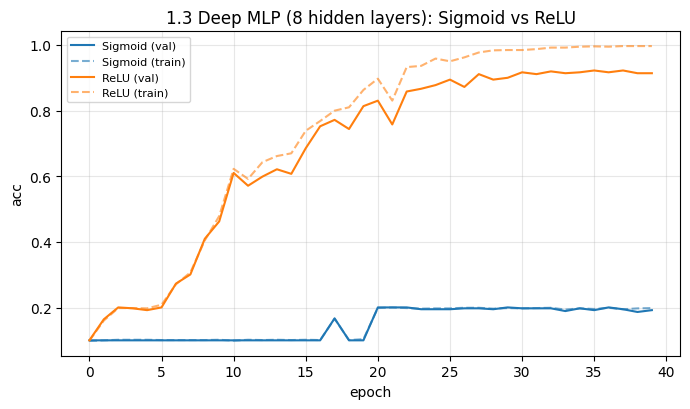


[Sigmoid 8층] 최종 train_acc = 0.1985 / val_acc = 0.1922
[ReLU    8층] 최종 train_acc = 0.9963 / val_acc = 0.9136
[참고: 1.2 얕은 2층 ReLU] val_acc = 0.9805


In [5]:
# ── 1.3 Vanishing Gradient 측정 ────────────────────────────────

def build_deep(act, depth=8, width=32, seed=MY_SEED):
    """은닉층을 depth 개 쌓은 깊은 MLP. act 만 바꿔 가며 비교한다."""
    torch.manual_seed(seed)
    layers, prev = [], 64
    for _ in range(depth):
        layers += [nn.Linear(prev, width), act()]
        prev = width
    layers.append(nn.Linear(prev, 10))
    return nn.Sequential(*layers)

def layerwise_grad_norms(model, X, y):
    """역전파를 한 번 돌리고, 각 Linear 층 weight 의 gradient L2 norm 을 리스트로 돌려준다."""
    model.train()
    model.zero_grad()
    loss = criterion(model(X), y)
    # TODO: 역전파를 수행해 각 파라미터의 .grad 를 채워라
    loss.backward() 
    norms = []
    for name, param in model.named_parameters():
        if name.endswith("weight"):
            # TODO: 이 층 gradient 의 L2 norm 을 float 로 담아라 (힌트: param.grad.norm().item())
            norms.append(param.grad.norm().item())
    return norms

# (1) 활성화 함수만 바꾼 두 깊은 네트워크의 층별 gradient 크기 비교
# TODO: 각각 nn.Sigmoid / nn.ReLU 를 넣어라 (클래스 자체를 넘긴다, 괄호 없이!)
deep_sig  = build_deep(act=nn.Sigmoid)
deep_relu = build_deep(act=nn.ReLU)

norms_sig  = layerwise_grad_norms(deep_sig,  Xtr, ytr)
norms_relu = layerwise_grad_norms(deep_relu, Xtr, ytr)

print("층 번호 1 = 입력에 가장 가까운 층,  마지막 = 출력층\n")
print("[Sigmoid] ", " ".join(f"{v:.2e}" for v in norms_sig))
print("[ReLU]    ", " ".join(f"{v:.2e}" for v in norms_relu))
print(f"\nSigmoid: 마지막층 / 첫번째층 = {norms_sig[-1] / norms_sig[0]:.3e} 배")
print(f"ReLU   : 마지막층 / 첫번째층 = {norms_relu[-1] / norms_relu[0]:.3e} 배")

# (2) 층별 gradient 크기 그래프 (y축은 log scale 이어야 차이가 보인다)
plt.figure(figsize=(7, 4.2))
layer_idx = np.arange(1, len(norms_sig) + 1)
plt.semilogy(layer_idx, norms_sig,  "o-", label="Sigmoid")
plt.semilogy(layer_idx, norms_relu, "s-", label="ReLU")
plt.xlabel("layer index (1 = closest to input)")
plt.ylabel("gradient L2 norm (log scale)")
plt.title("1.3 Layer-wise gradient magnitude (8 hidden layers)")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

# (3) 실제로 학습시켜 성능 차이 확인 (40 epoch)
hist_sig  = train_model(build_deep(act=nn.Sigmoid), epochs=40)
hist_relu = train_model(build_deep(act=nn.ReLU),    epochs=40)
plot_curves({"Sigmoid": hist_sig, "ReLU": hist_relu},
            "1.3 Deep MLP (8 hidden layers): Sigmoid vs ReLU", metric="acc")

print(f"\n[Sigmoid 8층] 최종 train_acc = {hist_sig['train_acc'][-1]:.4f} / "
      f"val_acc = {hist_sig['val_acc'][-1]:.4f}")
print(f"[ReLU    8층] 최종 train_acc = {hist_relu['train_acc'][-1]:.4f} / "
      f"val_acc = {hist_relu['val_acc'][-1]:.4f}")
print(f"[참고: 1.2 얕은 2층 ReLU] val_acc = {hist_base['val_acc'][-1]:.4f}")

**해석 질문 1.3 (본인 출력값 인용)**

1. **Sigmoid 네트워크의 첫 번째 층과 마지막 층의 gradient norm**을 적고, 몇 배 차이인지 쓰세요. ReLU는 몇 배였나요? 두 배율을 나란히 비교해 한 문장으로 결론지으세요.
*-> Sigmoid는 첫 층 1.65e-07, 마지막 층 2.90e-01로 1.758e+06배 차이이고, ReLU는 4.52e-04 -> 1.28e-02로 2.830e+01배다. 구조와 시드가 완전히 같고 활성화 함수 하나만 다른데 감쇠 배율이 6.2만 배 벌어졌다. Sigmoid의 첫 층은 gradient가 1e-07 수준이라 업데이트 신호가 사실상 0이고, ReLU에서 남은 28배는 활성화 때문이 아니라 층마다 곱해지는 가중치 행렬의 크기 때문이다.*

2. Sigmoid의 도함수 $\sigma'(z) = h(1-h) \le 0.25$ 를 이용해, **왜 Sigmoid에서만 이런 일이 생기는지** chain rule 식으로 설명하세요. ReLU의 도함수는 양수 구간에서 얼마인가요? 그래서 어떻게 되나요?
*-> 역전파의 오차 신호는 $\delta^{(k)} = \big(W^{(k+1)}\big)^{\top}\delta^{(k+1)} \odot \sigma'(z^{(k)})$ 로 한 층씩 거슬러 올라가고 첫 층 기울기는 $\partial L/\partial W^{(1)} = \delta^{(1)}x^{\top}$ 이므로, 입력층에 도달하기까지 $\sigma'$가 은닉층 수만큼 곱해진다. Sigmoid는 $\sigma'(z)=h(1-h)$ 이고 h = 0.5에서 얻는 최댓값조차 0.25이므로, 은닉층 8개를 통과하면 아무리 좋아도 $0.25^{8} = 1.53\times10^{-5}$ 배로 줄어든다. 실측 감쇠 $1/1.758\times10^{6} = 5.69\times10^{-7}$ 이 이 상한보다 더 작은 것은 대부분의 뉴런이 h = 0.5가 아닌 포화 구간에 있어 $\sigma'$가 0.25보다 훨씬 작기 때문이다. 즉 "0.25 이하를 반복해서 곱한다"는 구조 자체가 지수적 소멸을 만든다. 반면 ReLU의 도함수는 z > 0에서 정확히 1이라 몇 번을 곱해도 크기가 줄지 않고(z < 0에서는 0이지만 그 경로가 끊길 뿐 다른 경로는 그대로 살아 있다), 그래서 감쇠가 28배에 머문다. 처방이 non-saturating 활성화 함수인 이유가 여기에 있다.*

3. 학습 결과: Sigmoid 8층과 ReLU 8층의 최종 **train accuracy**를 적으세요. Sigmoid 쪽은 **train accuracy조차** 낮게 나왔을 것입니다. 이것이 과적합(overfitting) 문제와는 **완전히 다른 종류의 실패**인 이유를 설명하세요. (힌트: 과적합은 "train은 잘하는데 val이 나쁜" 것입니다.)
*-> Sigmoid는 train_acc 0.1985 / val_acc 0.1922, ReLU는 train_acc 0.9963 / val_acc 0.9136이다. Sigmoid의 0.1985는 §1.1에서 계산한 "한 클래스로 찍기" 10.18%에서 겨우 벗어난 수준으로, 40 epoch를 돌고도 훈련 데이터조차 외우지 못했다. 과적합은 train은 잘 맞히는데 val이 따라오지 않는 일반화의 실패이고 규제로 다룬다. 반면 이것은 앞쪽 층에 기울기가 도달하지 않아 학습이 시작조차 되지 않은 최적화의 실패, 곧 과소적합이다. 처방도 정반대다. 과적합에는 모델을 더 조여야 하지만, 여기서는 규제를 걸면 상황이 더 나빠지고 신호가 흐르도록 활성화 함수 교체, 적절한 초기화, BatchNorm, residual 연결 같은 수단을 써야 한다. train과 val을 함께 보아야 두 실패를 구분할 수 있다는 것이 이 실험의 교훈이다.*

4. §1.2의 **얕은(2층) ReLU** 모델의 val accuracy와 §1.3의 **깊은(8층) ReLU** 모델을 비교하세요. 층을 4배로 늘렸는데 성능이 좋아졌나요? 예상과 다르다면 그 원인으로 무엇을 의심하겠습니까? (§2-B에서 이어서 다룹니다.)
*-> 얕은 2층이 val 0.9805, 깊은 8층이 0.9136으로 층을 4배 늘렸더니 6.7%p 떨어졌다. 8층 쪽 train_acc가 0.9963이므로 표현력이나 수렴이 부족해서가 아니라 배운 것이 일반화되지 않은 것이다. 의심되는 원인은 세 가지다.*  
*첫째, 훈련 샘플이 1,078개뿐이라 8층이 감당하기에는 데이터가 부족하다.*  
*둘째, 입력이 8×8을 편 64차원 벡터라 층을 쌓아 조합할 계층적 부품 구조가 애초에 없다.*  
*셋째, ReLU에서도 초기 기울기가 28배 감쇠했듯 깊어질수록 최적화 자체가 어려워지는데 학습률과 규제는 얕은 모델 기준 그대로 썼다. §2-B에서 파라미터 수를 맞춰 다시 붙였을 때도 Wide가 5개 시드 전부에서 이겨 같은 결론이 재확인된다.*

5. **강의 서술형 퀴즈에 답하세요.** "Sigmoid를 hidden layer의 활성화 함수로 사용한 DNN에서 vanishing gradient가 발생하는 이유를 backpropagation의 chain rule 관점에서 설명하고, 이를 해결하는 방법을 **2가지 이상** 제시하시오." — 본인이 방금 잰 숫자를 근거로 인용해서 답하세요.
*-> 역전파는 출력층의 오차를 입력층 쪽으로 되돌리며 층마다 $(W^{(k)})^{\top}$과 활성화 함수의 도함수 $\sigma'(z^{(k)})$를 곱해 나간다. Sigmoid의 도함수는 $h(1-h)$로 최댓값이 0.25이고 입력이 조금만 커지거나 작아져도 0에 가까워지므로, 이 인자를 층 수만큼 반복해서 곱하면 앞쪽 층의 기울기가 지수적으로 0에 수렴한다. 은닉층 8개인 본 실험에서 이론적 상한은 $0.25^{8} = 1.53\times10^{-5}$ 배이고, 실제로 측정한 값은 마지막 층 2.90e-01 대 첫 층 1.65e-07로 1.758e+06배 차이, 즉 5.69e-07배까지 줄어 상한보다도 작았다. 기울기가 1e-07이라는 것은 그 층의 가중치를 바꿔도 손실이 사실상 변하지 않는다는 뜻이므로 앞쪽 층은 초기값에 고정된 채 남고, 그 결과 40 epoch를 학습해도 train accuracy가 0.1985로 무작위 추측 수준(0.10)에 머물렀다. 같은 구조에서 활성화 함수만 ReLU로 바꾸면 감쇠가 28.3배로 줄고 train accuracy가 0.9963에 도달한다.*  
*해결 방법은 다음과 같다.*  
*① non-saturating 활성화 함수 사용: ReLU는 양수 구간 도함수가 정확히 1이라 곱해도 크기가 보존된다. 죽은 뉴런이 걱정되면 Leaky ReLU나 GELU를 쓴다. 본 실험이 이 처방의 효과를 그대로 보여준다.*  
*② 가중치 초기화 개선: He 초기화처럼 층의 입력 차원에 맞춰 분산을 조정하면 순전파와 역전파 양쪽에서 신호의 분산이 층을 지나도 유지된다.*  
*③ Batch Normalization: 각 층의 입력을 정규화해 Sigmoid나 tanh를 쓰더라도 포화 구간이 아닌 기울기가 살아 있는 구간에 머물게 한다.*  
*④ Residual connection: 항등 경로를 열어 기울기가 활성화 함수를 거치지 않고 앞쪽 층까지 직접 흐르게 하며, 이 덕분에 수백 층 네트워크의 학습이 가능해졌다.*  
*⑤ 순환 신경망이라면 LSTM/GRU의 게이트 구조가 같은 역할을 한다.*

---

### 1.4 Issue 2) Overfitting — 네 가지 처방을 같은 조건에서 붙여 보기

강의 p.39는 과적합을 "Training error는 줄지만 Generalization 성능은 낮음 / **노이즈까지 기억하는** 상태"로 정의하고, 처방 네 가지를 제시했습니다.

| Remedy | 아이디어 | 이번 실험에서 |
|---|---|---|
| ① **Early Stopping** | val loss가 개선되지 않으면 중단 | `val_loss` 최저 epoch를 찾아 "여기서 멈췄어야 했다"를 확인 |
| ② **Data Augmentation** | label을 유지하는 노이즈 데이터로 robustness 향상 | (심화 §2-C에서 도전 가능) |
| ③ **L1/L2 Regularization** | `Loss = error + 모델 크기` | `weight_decay` 로 L2 적용, 강도 2단계 비교 |
| ④ **Dropout** | 매 스텝 유닛을 확률적으로 비활성화 | `p_drop=0.5` (강의 권장값: hidden 50%) |

**과적합을 일부러 만듭니다.** §1.2의 모델은 데이터가 충분해 과적합이 약했습니다. 그래서 이번엔 **훈련 데이터를 150개로 줄이고**(전체의 약 14%) 모델을 **256-256으로 키워** 극단적인 상황을 만듭니다. 데이터는 적고 파라미터는 많으니 모델이 150개를 통째로 외워 버리기 좋은 조건입니다.

**공정 비교의 원칙:** 네 조건에서 **바뀌는 것은 규제 하나뿐**이고 데이터·구조·시드·epoch 수는 모두 동일합니다. 그래야 차이의 원인을 규제로 돌릴 수 있습니다.

⚠️ **Dropout 주의:** `model.train()`일 때만 뉴런을 끄고, `model.eval()`에서는 모두 켠 채 스케일을 보정합니다(강의 p.43: "추론 시 출력에 p를 곱해 기댓값을 맞춘다"). §1.2에서 `evaluate()` 안에 `model.eval()`을 넣은 이유가 바로 이것입니다 — 빠뜨리면 평가할 때마다 결과가 달라집니다.

작은 훈련셋: torch.Size([150, 64]) | 원래 훈련셋: torch.Size([1078, 64])


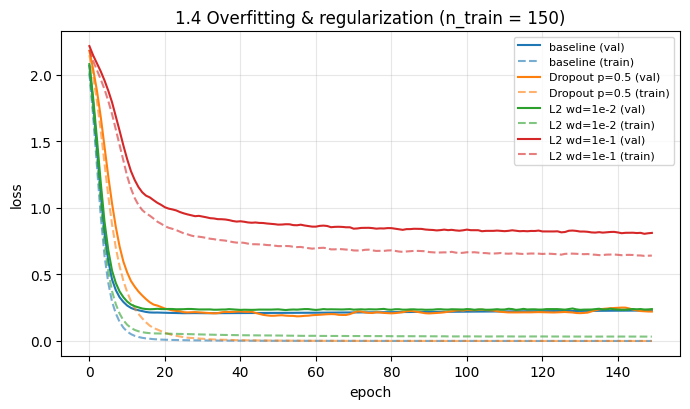

조건               train_loss  val_loss     gap  train_acc  val_acc  best_ep best_val_acc
----------------------------------------------------------------------------------------
baseline             0.0002    0.2293  0.2291     1.0000   0.9276       32       0.9387
Dropout p=0.5        0.0001    0.2212  0.2211     1.0000   0.9331       56       0.9415
L2 wd=1e-2           0.0330    0.2399  0.2070     1.0000   0.9359       53       0.9471
L2 wd=1e-1           0.6422    0.8126  0.1704     0.8733   0.8078      148       0.8245

[Early Stopping] baseline 은 epoch 32 에서 멈췄어야 했다. (실제로는 150 까지 돌렸으니 118 epoch 를 낭비)


In [6]:
# ── 1.4 과적합 만들고, 규제 네 가지 비교 ────────────────────────

# (1) 훈련 데이터를 150개로 줄여 과적합 상황을 만든다
rng = np.random.default_rng(MY_SEED)
# TODO: 훈련셋 인덱스 중 150개를 비복원추출하라 (힌트: rng.choice(len(Xtr), size=..., replace=False))
small_idx = rng.choice(len(Xtr), size= 150, replace= False )
Xsm, ysm = Xtr[small_idx], ytr[small_idx]
print("작은 훈련셋:", Xsm.shape, "| 원래 훈련셋:", Xtr.shape)

# (2) 규제만 바꿔 가며 동일 조건으로 학습
#     (모델은 모두 64 -> 256 -> 256 -> 10, epochs=150, batch_size=32)
configs = [
    # (이름,            dropout 확률, L2 강도(weight_decay))
    ("baseline",        0.0,  0.0),
    ("Dropout p=0.5",   0.5,  0.0),
    ("L2 wd=1e-2",      0.0,  1e-2),
    ("L2 wd=1e-1",      0.0,  1e-1),
]

hist14 = {}
for name, p_drop, wd in configs:
    # TODO: hidden=(256, 256) 이고 dropout 확률이 p_drop 인 모델을 만들어라
    m = build_mlp(hidden= (256,256), p_drop= p_drop)
    # TODO: 작은 훈련셋(Xsm, ysm)으로 150 epoch 학습. weight_decay 에 wd 를 전달할 것.
    hist14[name] = train_model(m, Xt=Xsm, yt=ysm, epochs=150,
                               weight_decay=wd, batch_size=32)

plot_curves(hist14, "1.4 Overfitting & regularization (n_train = 150)", metric="loss")

# (3) 요약표 — 과적합 정도(gap)와 Early Stopping 시점
print(f"{'조건':<16}{'train_loss':>11}{'val_loss':>10}{'gap':>8}"
      f"{'train_acc':>11}{'val_acc':>9}{'best_ep':>9}{'best_val_acc':>13}")
print("-" * 88)
for name, h in hist14.items():
    tl, vl = h["train_loss"][-1], h["val_loss"][-1]
    # TODO: val_loss 가 최소인 epoch (0-based index) 를 찾아라 -> Early Stopping 시점
    best = int(np.argmin(h['val_loss']))
    print(f"{name:<16}{tl:>11.4f}{vl:>10.4f}{vl - tl:>8.4f}"
          f"{h['train_acc'][-1]:>11.4f}{h['val_acc'][-1]:>9.4f}"
          f"{best + 1:>9}{max(h['val_acc']):>13.4f}")

# (4) Early Stopping 을 썼다면 몇 epoch 를 아꼈을까?
best_base = int(np.argmin(hist14["baseline"]["val_loss"])) + 1
print(f"\n[Early Stopping] baseline 은 epoch {best_base} 에서 멈췄어야 했다. "
      f"(실제로는 150 까지 돌렸으니 {150 - best_base} epoch 를 낭비)")

**해석 질문 1.4 (본인 출력값 인용)**

1. **baseline이 과적합했다는 증거**를 세 가지 숫자로 대세요: 마지막 `train_loss`, `train_acc`, 그리고 `val_loss - train_loss` (gap). 강의 p.39의 정의("Training error는 줄지만 Generalization 성능은 낮음")와 대응시켜 한 문장으로 쓰세요.
*-> train_loss 0.0002, train_acc 1.0000, gap 0.2291(= val_loss 0.2293 − 0.0002)이다. 파라미터 85,000여 개짜리 모델이 훈련 샘플 150개를 통째로 외워 훈련 오차를 0으로 만들었지만 val_loss는 그 1,000배 수준에 머물러 있으니, 훈련 오차의 감소가 일반화 성능으로 이어지지 않은 강의의 과적합 정의에 정확히 들어맞는다.*

2. `val_loss`가 최소였던 epoch는 baseline에서 몇이었나요? 전체 150 epoch 중 **몇 %** 지점인가요? Early Stopping이 왜 "**공짜에 가까운** 규제"라 불리는지(추가 파라미터도, 구조 변경도 없음) 본인 숫자로 설명하세요.
*-> epoch 32로 전체의 21.3% 지점이다. 나머지 118 epoch(78.7%)는 val 성능을 전혀 올리지 못한 채 훈련셋 암기만 진행한 구간이다. Early Stopping은 파라미터를 추가하지도, 구조를 바꾸지도, 손실 함수를 건드리지도 않고 루프를 멈추기만 한다. 치르는 비용이 없고 오히려 학습 시간을 79% 아끼므로 공짜에 가까운 규제라고 부른다. 다만 강의도 지적했듯 val 곡선은 매끄럽게 내려가지 않고 출렁이므로, tolerance를 두어 그 안에서 개선이 없을 때 멈추고 최저 시점의 가중치를 복원하는 방식으로 구현해야 한다(§2-C의 최종 모델이 이 방식이다).*

3. **Dropout p=0.5의 결과를 정직하게 보고하세요.** 최종 `val_loss`는 baseline보다 좋아졌나요, 나빠졌나요? 반대로 `best_val_acc`는 어땠나요? **두 지표가 다른 방향을 가리킨다면** 그 이유를 추론해 보세요. (힌트: 정확도는 "맞힌 개수", loss는 "확신의 정확성"을 잽니다.)
*-> Dropout은 val_loss 0.2212, best_val_acc 0.9415로 baseline(0.2293 / 0.9387)보다 두 지표가 모두 좋아졌다. 방향이 엇갈리지는 않았고 개선폭이 미미했을 뿐이다. 정확도 차이 0.0028은 val 359개 중 1개에 해당해 우연과 구별되지 않는다. 실질적인 변화는 성능이 아니라 시점에서 나타났다. val_loss 최저 epoch가 32 -> 56으로 밀렸으니, Dropout은 점수를 올렸다기보다 과적합이 시작되는 시점을 24 epoch 늦춘 것이다.*  
*두 지표가 실제로 엇갈린 조건은 `L2 wd=1e-2`다. val_loss는 0.2399로 baseline보다 나쁜데 best_val_acc는 0.9471로 네 조건 중 가장 좋다. 정확도는 argmax가 맞았는지만 세지만 loss는 정답에 얼마나 높은 확률을 줬는지를 잰다. weight decay가 가중치의 크기를 눌러 logit의 절대 크기가 작아지면 모든 예측의 확신도가 낮아지므로, 맞힌 샘플에서도 −log p가 커져 loss가 올라간다. 반대로 baseline은 확신이 과도해 맞힌 것의 loss는 0에 가깝지만 틀린 소수에서 큰 벌점을 받는다. 결국 "몇 개 맞혔나"와 "얼마나 잘 보정된 확률인가"는 별개의 질문이고, 모델 선택 기준을 미리 정해두지 않으면 같은 실험에서 반대 결론이 나온다.*

4. **L2 강도를 10배로 키운 `wd=1e-1`** 에서는 무슨 일이 일어났나요? `train_acc`와 `val_acc`를 함께 보고, 이것이 과적합인지 **과소적합(underfitting)** 인지 판정하세요. "규제는 세게 걸수록 좋다"는 말이 왜 틀렸는지 본인 숫자로 반박하세요.
*-> train_acc 0.8733 / val_acc 0.8078 / train_loss 0.6422로, gap은 0.1704로 네 조건 중 가장 작다. 하지만 훈련셋 150개조차 87%밖에 못 맞혔으니 이것은 과적합이 아니라 과소적합이다. 페널티가 너무 커서 최적화가 손실을 줄이는 대신 가중치를 0 쪽으로 끌어당기는 데 쓰인 결과다. 여기서 gap이 규제 성능의 지표가 될 수 없다는 점이 드러난다. 아무것도 학습하지 않는 모델은 gap이 0이지만 쓸모가 없다. 실제로 val_acc는 baseline 0.9276에서 0.8078로 12%p 떨어졌고, best_val_acc 기준으로도 0.9471(wd=1e-2)에서 0.8245로 무너졌다. wd를 0 -> 1e-2 -> 1e-1로 키웠을 때 best_val_acc가 0.9387 -> 0.9471 -> 0.8245로 올랐다가 꺾이므로, 규제 강도에는 최적점이 있고 그 지점은 val로 찾아야 한다. 강의가 과적합을 Bias–Variance trade-off로 설명한 그대로 규제는 variance를 줄이는 대신 bias를 키우며, wd=1e-1은 그 교환이 손해로 넘어간 지점이다. "세게 걸수록 좋다"는 이 곡선의 왼쪽 절반만 본 주장이다.*

5. 네 조건 중 **본인 데이터에서 가장 좋았던 것**은 무엇인가요? 그 결과가 강의 슬라이드의 서술과 일치했나요, 어긋났나요? 어긋났다면 원인으로 무엇을 의심하겠습니까? (힌트: 훈련 샘플 150개에 뉴런의 절반을 끄면 어떻게 될까요?)
*-> best_val_acc 기준으로는 `L2 wd=1e-2`(0.9471)가 1위, Dropout(0.9415), baseline(0.9387), `wd=1e-1`(0.8245) 순이다. 강의는 hidden layer에 50% Dropout을 권장했지만 여기서는 L2가 근소하게 앞섰고 Dropout의 이득도 baseline 대비 0.0028에 그쳤다. 원인으로 두 가지를 의심한다.*  
*첫째, 훈련 샘플이 150개인데 매 스텝 뉴런의 절반을 끄면 유효 모델과 유효 데이터가 동시에 줄어 기울기 추정의 잡음이 커진다. 강의가 든 Dropout의 목적은 특정 뉴런 조합의 co-adaptation을 막고 매 스텝 다른 서브네트워크를 학습시키는 것인데, 150개를 이미 통째로 외울 수 있는 상황에서는 어느 서브네트워크든 그 150개를 외워 버리므로 목적 자체가 힘을 잃는다.*  
*둘째, 상위 세 조건의 best_val_acc 차이가 0.9387~0.9471로 val 359개 기준 3개 차이에 불과하다. 이 정도 간격을 단일 시드 한 번으로 서열화하는 것은 무리이며, §2-B처럼 여러 시드로 반복해야 순위를 주장할 수 있다. 그런 의미에서 이 데이터에서 확실하게 이득이 검증된 처방은 네 조건 중 어느 규제도 아니라 118 epoch를 절약해 준 Early Stopping이다.*

---

### 1.5 Issue 3) Optimization — SGD / Momentum / Adam을 같은 출발선에서

강의 p.45~50은 optimizer의 계보를 보여 줬습니다.

$$\text{GD} \to \text{SGD(minibatch)} \to \text{Momentum},\ \text{RMSProp} \to \text{Adam}$$

- **Mini-batch SGD**: 전체가 아닌 일부로 gradient를 계산해 **자주** 업데이트
- **Momentum**: `업데이트 = 현재 gradient + 과거 gradient` — 방향이 자주 바뀌는 축은 상쇄, 일관된 축은 가속 -> 지그재그 완화, 안장점 탈출
- **Adaptive (AdaGrad -> RMSProp)**: gradient가 컸던 파라미터는 학습률을 줄이고 작았던 파라미터는 키움
- **Adam**: Momentum(**방향**) + RMSProp(**크기**) = "어디로 + 얼마나"

**실험 설계** — 모델·데이터·시드·epoch를 완전히 고정하고 **optimizer만** 바꿉니다. 학습률이 optimizer마다 적정 범위가 다르므로, SGD 계열은 `lr=0.05`, Adam은 관례적 기본값 `lr=0.001`을 씁니다. 여기에 **일부러 학습률을 크게 준 `SGD lr=3.0`** 도 넣어 무슨 일이 벌어지는지 봅니다.

비교 지표는 두 가지입니다: **① 최종 성능**(어디까지 갔나)과 **② 수렴 속도**(val accuracy 90%에 몇 epoch만에 도달했나).

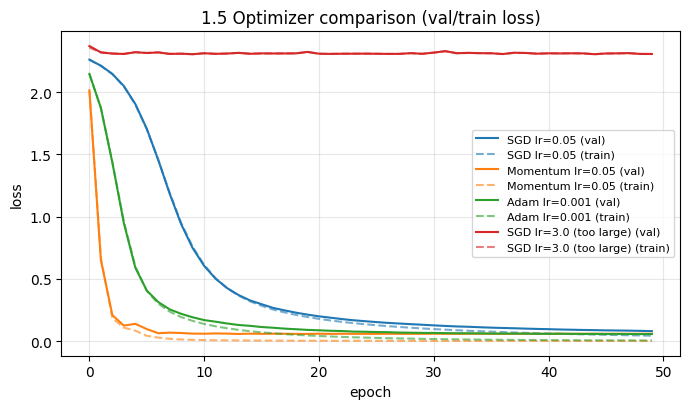

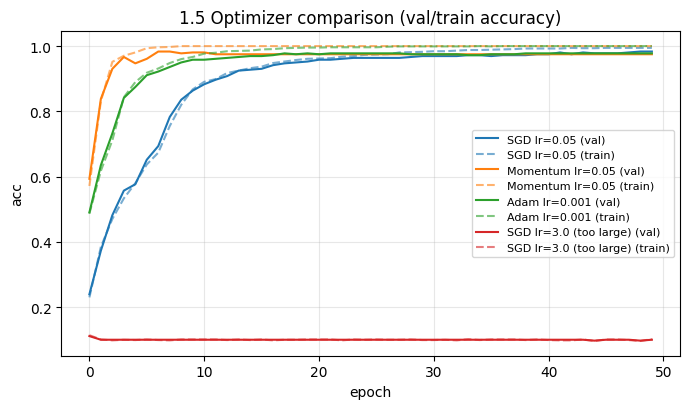

optimizer            ep1 val_loss  final train_loss  final val_acc  best val_acc  first ep >= 90%
-------------------------------------------------------------------------------------------------
SGD lr=0.05                2.2620            0.0434         0.9833        0.9833               13
Momentum lr=0.05           2.0156            0.0008         0.9749        0.9833                3
Adam lr=0.001              2.1470            0.0048         0.9777        0.9777                6
SGD lr=3.0 (too large)       2.3710            2.3069         0.1003        0.1114             None


In [8]:
# ── 1.5 Optimizer 비교 ─────────────────────────────────────────
opt_configs = [
    # (이름,               opt_name,     learning rate)
    ("SGD lr=0.05",        "sgd",        0.05),
    ("Momentum lr=0.05",   "momentum",   0.05),
    ("Adam lr=0.001",      "adam",       1e-3),
    ("SGD lr=3.0 (too large)",  "sgd",        3.0),
]

hist15 = {}
for name, opt_name, lr in opt_configs:
    # TODO: 모든 조건에서 동일한 구조 (64, 32) 의 모델을 새로 만들어라
    #       (같은 모델 객체를 재사용하면 앞 실험의 학습 결과가 남아 비교가 무의미해진다!)
    m = build_mlp(hidden=(64,32))
    # TODO: opt_name 과 lr 을 전달해 50 epoch 학습
    hist15[name] = train_model(m, epochs=50, opt_name=opt_name, lr=lr)

plot_curves(hist15, "1.5 Optimizer comparison (val/train loss)", metric="loss")
plot_curves(hist15, "1.5 Optimizer comparison (val/train accuracy)", metric="acc")

# 수렴 속도: val accuracy 가 처음으로 90% 를 넘은 epoch
print(f"{'optimizer':<20}{'ep1 val_loss':>13}{'final train_loss':>18}"
      f"{'final val_acc':>15}{'best val_acc':>14}{'first ep >= 90%':>17}")
print("-" * 97)
for name, h in hist15.items():
    # TODO: val_acc 가 처음으로 0.90 이상이 되는 epoch 번호를 찾아라 (없으면 None)
    first90 = next((i + 1 for i, v in enumerate(h["val_acc"]) if v >= 0.9), None)
    print(f"{name:<20}{h['val_loss'][0]:>13.4f}{h['train_loss'][-1]:>18.4f}"
          f"{h['val_acc'][-1]:>15.4f}{max(h['val_acc']):>14.4f}{str(first90):>17}")

**해석 질문 1.5 (본인 출력값 인용)**

1. **SGD / Momentum / Adam이 val accuracy 90%에 도달한 epoch**를 각각 적으세요. Momentum이 순수 SGD보다 빠른 이유를, 강의 p.48의 "**방향이 자주 바뀌는 움직임은 줄이고, 계속 같은 방향으로 이동할 때는 속도를 높인다**"로 설명하세요.
*-> SGD 13 epoch, Momentum 3 epoch, Adam 6 epoch이고 `SGD lr=3.0`은 끝내 도달하지 못했다. SGD와 Momentum은 학습률이 0.05로 동일하고 momentum 계수 0.9만 다른데 도달 시점이 4배 이상 차이 난다. 미니배치 기울기는 배치마다 방향이 흔들리는 성분과 손실이 실제로 줄어드는 일관된 성분이 섞여 있다. 과거 업데이트를 관성으로 더하면 매번 부호가 바뀌는 성분은 서로 상쇄되고 계속 같은 부호를 유지하는 성분만 누적되어, 좁고 긴 골짜기에서 벽면을 오가는 지그재그가 줄고 골짜기를 따라가는 속도가 붙는다. 계수 0.9는 대략 최근 10스텝을 평균 내는 효과에 해당하며, 같은 학습률로 실효 보폭을 키우는 것과 같다. 안장점처럼 기울기가 거의 0인 지점도 이 관성 덕분에 지나칠 수 있다.*

2. **최종 val accuracy**는 셋이 얼마나 차이 났나요? "수렴이 빠르다"와 "최종 성능이 좋다"가 같은 말인지 본인 숫자로 판단하세요.
*-> 최종 val_acc는 SGD 0.9833 / Momentum 0.9749 / Adam 0.9777이고, best val_acc는 0.9833 / 0.9833 / 0.9777이다. 가장 느렸던 SGD가 최종 성능은 가장 높고, 가장 빨랐던 Momentum은 중간이다. 두 개념은 같은 말이 아니다. 수렴 속도는 도달에 걸린 시간이고 최종 성능은 도달한 지점의 높이라서, 빨리 내려간 optimizer가 더 얕은 극소점에 먼저 자리 잡을 수도 있다. 다만 셋의 차이 0.0084는 val 359개 중 3개에 해당하므로 이 데이터에서 정직한 결론은 "세 optimizer의 도달 지점은 사실상 같고 도달 속도만 다르다"이다. 성능 순위를 주장하려면 여러 시드에서 반복해야 한다.*

3. **`SGD lr=3.0`** 에서 무슨 일이 일어났나요? `val_loss` 값을 적고, 그 값이 $\ln(10) \approx 2.303$ 에 가까운 것이 무엇을 의미하는지 생각해 보세요. (힌트: 10개 클래스에 균등 확률을 주는 모델의 cross entropy는 얼마일까요?)
*-> ep1 val_loss 2.3710, 최종 train_loss 2.3069, val_acc 0.1003(최고 기록도 0.1114)으로 50 epoch 내내 아무것도 배우지 못했다. 10개 클래스에 균등 확률 0.1을 주는 모델의 cross entropy가 $-\ln(0.1) = \ln(10) = 2.3026$이므로, loss가 여기 붙어 있다는 것은 모델이 입력과 무관한 값을 내놓고 있다는 뜻이다. 학습률 3.0이면 한 스텝의 보폭이 골짜기 폭보다 커서 최소점을 계속 지나치며 튕기고, 그 과정에서 가중치가 크게 밀려나 ReLU의 입력이 음수 영역에 고정되면 출력도 기울기도 0이 되어 그 뉴런이 죽는다. 같은 시드로 학습된 모델을 열어 보니 두 번째 ReLU 층은 훈련 1,078장 전체에서 단 하나의 뉴런도 켜지지 않았고(생존 비율 0.000), 출력 logit의 샘플 간 표준편차는 0.000e+00으로 어떤 이미지를 넣어도 같은 값이 나왔다. 이 모델은 test 360장을 전부 클래스 3으로 예측했으며, val_acc 0.1003은 §1.1에서 계산한 "무조건 한 클래스로만 찍는" 모델의 정확도와 정확히 일치한다(val 359개 중 클래스 3이 36개). NaN으로 발산한 것이 아니라 입력을 무시하는 상수 함수로 주저앉은 것이고, train_loss가 ln(10)보다 아주 조금 큰 것도 그 상수가 완전한 균등이 아니라 한 클래스로 치우쳐 있기 때문이다. loss 곡선이 2.30 근처에서 평평하면 optimizer가 아니라 학습률부터 의심해야 한다.*

4. 강의 객관식 퀴즈의 보기 ①과 ⑥은 **틀린 설명**입니다. 각각 어디가 틀렸는지 고쳐 쓰세요.
   - ① "미니배치 SGD는 full-batch GD에 비해 한 epoch당 파라미터 업데이트 횟수가 줄어드는 대신, 각 업데이트에서 계산되는 gradient 추정치가 더 정확하다."
*-> 두 부분이 모두 반대다. full-batch GD는 한 epoch에 업데이트를 1회 하지만, 미니배치 SGD는 데이터를 배치 크기로 나눈 횟수만큼 업데이트한다. 이 과제에서는 훈련 1,078개를 batch_size 64로 나눠 epoch당 17회다. 또 미니배치 기울기는 전체 기울기의 불편추정량이기는 하나 표본이 작아 분산이 크므로 개별 추정치는 오히려 덜 정확하다. 고쳐 쓰면 "미니배치 SGD는 full-batch GD에 비해 한 epoch당 파라미터 업데이트 횟수가 늘어나는 대신, 각 업데이트에서 계산되는 gradient 추정치의 분산이 커진다(덜 정확하다)"이다. 그럼에도 미니배치를 쓰는 이유는 부정확한 업데이트를 자주 하는 편이 정확한 업데이트를 드물게 하는 것보다 같은 계산량에서 빠르고, 그 잡음이 얕은 극소점을 빠져나오는 데 도움이 되기 때문이다.*
   - ⑥ "RMSProp의 decay rate $\rho$를 0에 가깝게 설정할수록 과거 gradient의 영향이 오래 유지되어 AdaGrad와 유사하게 동작한다."
*-> $\rho$의 방향이 반대다. RMSProp의 누적식은 $E[g^2]_t = \rho\,E[g^2]_{t-1} + (1-\rho)\,g_t^2$ 이므로 $\rho \to 0$이면 직전까지의 항이 사라지고 현재 기울기만 남아 과거를 즉시 잊는다. 반대로 $\rho \to 1$이면 과거 항이 거의 감쇠 없이 유지되어, 모든 과거 기울기 제곱을 그대로 더하는 AdaGrad에 가까워진다. 고쳐 쓰면 "RMSProp의 decay rate $\rho$를 1에 가깝게 설정할수록 과거 gradient의 영향이 오래 유지되어 AdaGrad와 유사하게 동작한다"이다. AdaGrad가 학습 후반에 분모가 무한히 커져 학습이 멈추는 문제를 RMSProp이 지수이동평균으로 푼 것이므로, $\rho$는 "과거를 얼마나 오래 기억할지"를 정하는 값이며 흔히 0.9를 쓴다.*

5. Adam은 **Momentum(방향) + RMSProp(크기)** 라고 배웠습니다. 위 실험에서 Adam이 SGD보다 훨씬 작은 학습률(0.001 vs 0.05)을 쓰고도 더 빨리 수렴한 이유를, "파라미터마다 학습률을 다르게 준다"는 성질과 연결해 설명하세요.
*-> SGD의 이동 거리는 lr × (기울기 크기)라서 기울기가 작은 파라미터는 거의 움직이지 않지만, Adam은 $\hat{m}/(\sqrt{\hat{v}}+\epsilon)$ 형태로 각 파라미터의 기울기를 자신의 최근 크기로 나눈다. 그 결과 스텝의 크기가 기울기의 절대 크기가 아니라 신호 대 잡음비로 정해지고, 대부분의 파라미터에서 이동 거리가 lr 근처로 정규화된다. 따라서 Adam의 0.001과 SGD의 0.05는 서로 다른 척도의 숫자이며 직접 비교할 수 없다. Adam에서 lr은 사실상 한 스텝의 이동 거리 상한에 가깝다. 이 성질 덕분에 기울기가 작아 SGD였다면 방치되었을 파라미터도 같은 속도로 움직여 6 epoch 만에 90%에 도달했다. 이 데이터에서 특히 유리한 이유도 있다. 표준화를 했어도 §1.1에서 확인했듯 항상 0인 테두리 픽셀 때문에 입력 열마다 스케일이 다르고, §1.3에서 봤듯 층마다 기울기 크기가 수십 배씩 차이 난다. 파라미터별 적응적 스케일링은 정확히 이런 이질성을 흡수한다. 대신 lr을 세밀하게 맞추지 않아도 무난히 학습된다는 것이 장점일 뿐 최종 성능까지 최고라는 뜻은 아니며, 실제로 이 실험의 최종 val_acc는 SGD 0.9833이 Adam 0.9777보다 높았다.*

---

# 2. 심화 과제 — 스스로 생각하기

여기까지는 "돌리면 나오는" 영역이었습니다. 진짜 실력은 **그 값을 어떻게 읽고 판단하느냐**에서 갈립니다.
아래 세 문제는 모두 **강의 슬라이드가 주장한 것을 본인 실험으로 검증하거나 반증**하는 구조입니다. 슬라이드와 다른 결과가 나오면 **그대로 쓰고 원인을 추론**하세요.

---

### 2-A. 활성화 함수를 없애면? — "층을 쌓아도 선형"임을 직접 증명

강의 p.21은 이렇게 묻고 답했습니다.

> **Q. Why neural networks use Activation Functions?**
> **A. To introduce non-linearities into the network**

강의에서 수식으로 설명한 주장을 이제 **실험으로 확인**합니다. 활성화 함수 자리에 `nn.Identity()`(아무것도 안 하는 층)를 넣어 **은닉층이 2개인데도 사실은 선형 모델**인 네트워크를 만들고, 세 가지를 비교합니다.

| 모델 | 구조 | 파라미터 수 |
|---|---|---|
| **linear-deep** | 64 -> 64 -> 32 -> 10, 활성화 **없음** | 6,570 |
| **single Linear** | 64 -> 10, 은닉층 자체가 없음 | 650 |
| **ReLU MLP** (§1.2) | 64 -> 64 -> 32 -> 10, ReLU | 6,570 |

그리고 **결정적 증거**로, linear-deep의 가중치 행렬 세 개를 곱해 **하나의 $10\times64$ 행렬로 접은 뒤**, 그 단일 선형변환이 원래 네트워크와 **똑같은 출력**을 내는지 확인합니다.

$$
W_{\text{eq}} = W^{(3)}W^{(2)}W^{(1)}, \qquad
b_{\text{eq}} = W^{(3)}\big(W^{(2)}b^{(1)} + b^{(2)}\big) + b^{(3)}
$$

In [9]:
# ── 2-A. 활성화 함수를 없애면 정말 선형 모델인가? ────────────────

# (1) 세 모델 학습 (조건 동일: Adam, 60 epoch)
# TODO: 활성화 함수 자리에 '아무 일도 하지 않는' 층을 넣어라 (힌트: nn.Identity)
lin_deep = build_mlp(hidden=(64, 32), act= nn.Identity)
single   = build_mlp(hidden=(),       act=nn.Identity)   # 은닉층 없음 = 그냥 Linear(64 -> 10)
relu_mlp = build_mlp(hidden=(64, 32), act=nn.ReLU)

h_lin  = train_model(lin_deep, epochs=60)
h_sing = train_model(single,   epochs=60)
h_relu = train_model(relu_mlp, epochs=60)

print(f"{'model':<26}{'params':>8}{'test_acc':>10}")
print("-" * 44)
for tag, m in [("linear-deep (64,32)", lin_deep),
               ("single Linear(64->10)", single),
               ("ReLU MLP (64,32)", relu_mlp)]:
    # TODO: test 세트에서 정확도를 구해 출력하라
    _, acc = evaluate(model= m,X=Xte, y=yte)
    print(f"{tag:<26}{count_params(m):>8}{acc:>10.4f}")

# (2) 결정적 증거: 가중치 세 개를 곱해 '하나의 선형변환'으로 접어 본다
Ws = [layer.weight.detach() for layer in lin_deep if isinstance(layer, nn.Linear)]
Bs = [layer.bias.detach()   for layer in lin_deep if isinstance(layer, nn.Linear)]

# TODO: W_eq = W3 @ W2 @ W1  (Ws[0]=W1, Ws[1]=W2, Ws[2]=W3)
W_eq = Ws[2]@Ws[1]@Ws[0]
b_eq = Ws[2] @ (Ws[1] @ Bs[0] + Bs[1]) + Bs[2]
print(f"\n접은 뒤 W_eq shape = {tuple(W_eq.shape)}  (원래 3개 행렬: "
      f"{tuple(Ws[0].shape)}, {tuple(Ws[1].shape)}, {tuple(Ws[2].shape)})")

with torch.no_grad():
    out_folded   = Xte @ W_eq.T + b_eq      # 접은 단일 선형변환의 출력
    out_original = lin_deep(Xte)            # 원래 3층 네트워크의 출력
    max_diff = (out_folded - out_original).abs().max().item()
print(f"두 출력의 최대 차이 = {max_diff:.3e}   <- 0에 가까우면 '완전히 같은 함수'라는 뜻")

# (3) ReLU 네트워크는 접을 수 있을까? (같은 방식으로 시도해 보고 결과를 관찰하라)
Ws_r = [layer.weight.detach() for layer in relu_mlp if isinstance(layer, nn.Linear)]
Bs_r = [layer.bias.detach()   for layer in relu_mlp if isinstance(layer, nn.Linear)]
W_eq_r = Ws_r[2] @ Ws_r[1] @ Ws_r[0]
b_eq_r = Ws_r[2] @ (Ws_r[1] @ Bs_r[0] + Bs_r[1]) + Bs_r[2]
with torch.no_grad():
    diff_r = (Xte @ W_eq_r.T + b_eq_r - relu_mlp(Xte)).abs().max().item()
print(f"[ReLU 네트워크에 같은 접기를 시도] 최대 차이 = {diff_r:.3e}")

model                       params  test_acc
--------------------------------------------
linear-deep (64,32)           6570    0.9444
single Linear(64->10)          650    0.9556
ReLU MLP (64,32)              6570    0.9694

접은 뒤 W_eq shape = (10, 64)  (원래 3개 행렬: (64, 64), (32, 64), (10, 32))
두 출력의 최대 차이 = 9.537e-06   <- 0에 가까우면 '완전히 같은 함수'라는 뜻
[ReLU 네트워크에 같은 접기를 시도] 최대 차이 = 5.271e+01


**Q2-A. (직접 돌려서 관찰 + 판단)**

**(1) 돌리기 전에 예측 먼저.** `linear-deep`(파라미터 6,570개)과 `single Linear`(650개) 중 어느 쪽 test accuracy가 높을지, **돌리기 전에** 한 줄로 적어 두세요. 파라미터가 10배 많으니 더 좋을까요?
*-> 예측: 비슷하거나 single Linear가 근소하게 나을 것이다. 활성화 함수가 없으면 두 모델이 표현하는 함수 집합은 똑같이 "64차원 입력에 대한 아핀변환 하나"라 늘어난 파라미터 5,920개는 표현력이 아니라 중복이고, 하나로 끝날 변환을 행렬 세 개로 쪼개 놓은 만큼 같은 60 epoch 안에서 수렴은 오히려 까다로워질 수 있다.*

**(2) 본인 값 인용.** 세 모델의 test accuracy를 적으세요.
- linear-deep = ____ / single Linear = ____ / ReLU MLP = ____
*-> linear-deep = 0.9444 (6,570 params) / single Linear = 0.9556 (650 params) / ReLU MLP = 0.9694 (6,570 params). 파라미터를 10배 더 쓴 linear-deep이 single Linear보다 1.1%p 낮고, 같은 파라미터 수에서 ReLU를 넣은 쪽만 2.5%p 높다. 성능을 만든 것은 파라미터 수가 아니라 비선형성이다.*

**(3) 결정적 증거 해석.** "두 출력의 최대 차이"는 얼마였나요? 이 값이 0이 아니라 $10^{-5}$ 정도인 이유는 무엇인가요? (힌트: `torch.float32`의 유효자릿수) 그리고 이 실험이 **왜 정확도 비교보다 강한 증거**인지 설명하세요. (정확도는 0.93 vs 0.92처럼 조금 다를 수 있지만, 이 실험은 무엇을 보여 주나요?)
*-> 최대 차이는 9.537e-06이다. `torch.float32`의 유효 십진 자릿수는 약 7자리(machine epsilon 1.19e-07)이고 logit의 크기가 10 안팎이므로 상대오차 1e-07 × 값 크기 10에 행렬을 세 번 곱하며 쌓인 반올림이 더해져 1e-05 수준이 나온다. 수학적으로는 완전히 같은 함수이고 남은 차이는 순전히 부동소수점 오차다(같은 가중치를 float64로 접으면 2.132e-14까지 줄어든다). 정확도 비교는 "두 모델의 성능이 비슷하다"까지만 말할 수 있고, 0.9444 대 0.9556처럼 다르게 나오면 오히려 다른 모델이라는 인상을 준다. 반면 접기 실험은 test 360장 전부에서, 모든 클래스의 logit 값이 소수점 다섯째 자리까지 일치함을 보인다. 즉 "성능이 비슷한 두 모델"이 아니라 "가중치가 다르게 생겼을 뿐 입력마다 같은 값을 내놓는 하나의 함수"라는 것을 개별 샘플 단위로 증명한다. 성능은 우연히 같을 수 있지만 모든 입력에 대한 출력이 같을 수는 없다.*

**(4) 반대 실험.** ReLU 네트워크에 같은 접기를 시도했을 때 차이는 얼마였나요? 왜 ReLU는 접히지 않는지, "$\max(0, z)$ 는 행렬곱으로 표현할 수 없다"는 사실과 연결해 설명하세요.
*-> 5.271e+01로 선형 쪽 오차 9.537e-06보다 550만 배 크다. 이 크기는 수치 오차가 아니라 아예 다른 함수라는 뜻이다. 행렬곱과 덧셈은 몇 번을 합성해도 하나의 아핀사상으로 접히지만, $\max(0,z)$는 입력의 부호에 따라 다른 선형식을 적용하는 조각별 선형함수다. ReLU 네트워크를 굳이 행렬로 쓰면 켜진 뉴런만 남기는 대각 마스크 $D(x)$를 끼워 $W^{(3)}D_2(x)W^{(2)}D_1(x)W^{(1)}$ 형태가 되는데, 이 $D(x)$가 입력마다 달라지므로 유효 행렬 자체가 입력의 함수다. 고정된 하나의 $W_{eq}$로 뽑아낼 수 없는 이유가 여기에 있다. 뒤집어 말하면 ReLU 네트워크는 입력 공간을 뉴런의 on/off 패턴에 따라 수많은 영역으로 쪼개고 각 영역에서 서로 다른 선형함수를 쓰는 모델이며, 층이 깊어질수록 이 영역의 수가 늘어 표현할 수 있는 함수가 넓어진다.*

**(5) 본인 언어로.** 위 결과를 종합해, 강의 p.21의 **"To introduce non-linearities into the network"** 가 정확히 무슨 뜻인지 한 문단으로 쓰세요. "활성화 함수가 없으면 층을 100개 쌓아도 ____ 와 같다"는 문장을 반드시 포함하세요.
*-> 활성화 함수가 없으면 층을 100개 쌓아도 은닉층이 하나도 없는 단층 선형모델, 즉 `Linear(64->10)` 하나와 같다. 선형변환의 합성은 다시 선형변환이라 층을 아무리 늘려도 함수의 형태가 아니라 그 함수를 적는 방식만 복잡해지기 때문이다. 이 과제에서 은닉층 2개짜리 linear-deep의 가중치 세 개를 곱해 하나의 10×64 행렬로 접었을 때 원래 네트워크와의 출력 차이가 9.537e-06, 곧 float32 오차 수준이었던 것이 그 직접적인 증거이고, 파라미터를 10배 쓴 linear-deep(0.9444)이 650개짜리 single Linear(0.9556)를 이기지 못한 것이 그 실용적 귀결이다. 반대로 같은 구조에 ReLU만 끼운 모델은 같은 방식으로 접으면 오차가 5.271e+01로 벌어져 접히지 않았고, test accuracy는 0.9694로 올라갔다. 결국 층을 쌓는 의미는 파라미터를 늘리는 데 있는 것이 아니라, 층 사이에 접히지 않는 비선형 함수를 끼워 넣어 모델이 표현할 수 있는 함수의 집합 자체를 넓히는 데 있다. 활성화 함수는 층을 진짜 층으로 만들어 주는 장치다.*

---

### 2-B. Go Wider or Deeper? — 파라미터 수를 맞춰 놓고 공정하게 붙이기

강의 p.36은 이렇게 결론지었습니다.

> 모델 용량을 단순히 폭으로 늘리는 것보다(Wide), 적절한 구조를 가진 깊은 네트워크(Deep)가
> **파라미터를 더 효율적으로 사용해 높은 성능**을 낼 수 있다.

이 주장을 **공정하게** 검증하려면 두 모델의 **파라미터 수를 비슷하게 맞춰야** 합니다. 파라미터가 많은 쪽이 이기면 그건 구조의 승리가 아니라 용량의 승리니까요.

**설계**
- **Wide**: `64 -> H -> 10` (은닉층 1개) -> 파라미터 수 $= 75H + 10$
- **Deep**: `64 -> h -> h -> h -> h -> 10` (은닉층 4개) -> 파라미터 수 $= 3h^2 + 78h + 10$

$H = 256$ 이면 19,210개. 이와 **10% 이내**로 맞는 $h$를 직접 찾아 넣으세요.

> ⚠️ **결과가 강의 슬라이드와 다르게 나올 수 있습니다.** 그래도 그대로 보고하고 원인을 추론하세요. 시드 하나로 결론 내리지 말고 **여러 시드에서 반복**해 보는 것이 이 절의 진짜 과제입니다.

Wide 64-256-10 파라미터 수 = 19210
Deep 64-68x4-10 파라미터 수 = 19186
파라미터 수 차이 = 0.12%  -> 10% 이내여야 공정한 비교
Wide (1 x 256)   final val_acc = 0.9889 | best val_acc = 0.9889 | test_acc = 0.9750 | final train_loss = 0.0031
Deep (4 x 68)    final val_acc = 0.9666 | best val_acc = 0.9666 | test_acc = 0.9722 | final train_loss = 0.0003


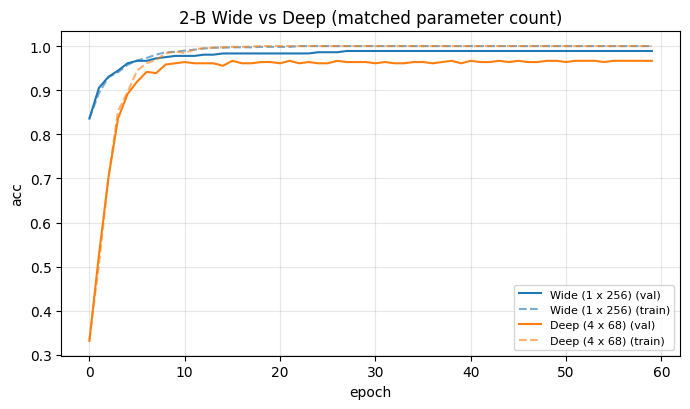


[여러 시드에서 반복]
  seed=0      wide=0.9750  deep=0.9528
  seed=1      wide=0.9750  deep=0.9583
  seed=42     wide=0.9722  deep=0.9639
  seed=9356   wide=0.9750  deep=0.9722
  seed=7777   wide=0.9806  deep=0.9722

Wide 평균 = 0.9756 (표준편차 0.0027)
Deep 평균 = 0.9639 (표준편차 0.0077)
Wide 가 이긴 횟수: 5 / 5


In [11]:
# ── 2-B. Wide vs Deep (파라미터 수를 맞춘 공정 비교) ─────────────

# (1) 파라미터 수 맞추기 — Deep 쪽 h 를 직접 찾으세요
H = 256
wide = build_mlp(hidden=(H,))
print(f"Wide 64-{H}-10 파라미터 수 = {count_params(wide)}") # 19210


# TODO: 은닉층 4개짜리 Deep 모델의 폭 h 를 정하라.
#       3h^2 + 78h + 10 이 위 숫자와 10% 이내가 되도록. (h 를 몇 개 넣어 보며 찾아도 좋다)
h = min(range(20,100), key= lambda x: abs(3*x**2+78*x+10-count_params(wide)))

deep = build_mlp(hidden=(h, h, h, h))
print(f"Deep 64-{h}x4-10 파라미터 수 = {count_params(deep)}")

diff_pct = abs(count_params(wide) - count_params(deep)) / count_params(wide) * 100
print(f"파라미터 수 차이 = {diff_pct:.2f}%  -> 10% 이내여야 공정한 비교")
assert diff_pct < 10, "파라미터 수가 10% 넘게 차이납니다. h 를 다시 고르세요."

# (2) 동일 조건으로 학습 후 비교
hist2b = {}
for tag, m in [(f"Wide (1 x {H})", wide), (f"Deep (4 x {h})", deep)]:
    hist2b[tag] = train_model(m, epochs=60)
    _, te_acc = evaluate(m, Xte, yte)
    print(f"{tag:<16} final val_acc = {hist2b[tag]['val_acc'][-1]:.4f} | "
          f"best val_acc = {max(hist2b[tag]['val_acc']):.4f} | test_acc = {te_acc:.4f} | "
          f"final train_loss = {hist2b[tag]['train_loss'][-1]:.4f}")

plot_curves(hist2b, "2-B Wide vs Deep (matched parameter count)", metric="acc")

# (3) 시드 하나로 결론 내지 않기 — 5개 시드에서 반복
print("\n[여러 시드에서 반복]")
wide_scores, deep_scores = [], []
for s in [0, 1, 42, MY_SEED, 7777]:
    w = build_mlp(hidden=(H,), seed=s)
    d = build_mlp(hidden=(h, h, h, h), seed=s)
    train_model(w, epochs=60, seed=s)
    train_model(d, epochs=60, seed=s)
    # TODO: 각 모델의 test accuracy 를 리스트에 담아라
    wide_scores.append(evaluate(w,X=Xte, y=yte)[-1])
    deep_scores.append(evaluate(d,X=Xte, y=yte)[-1])
    print(f"  seed={s:<6} wide={wide_scores[-1]:.4f}  deep={deep_scores[-1]:.4f}")

print(f"\nWide 평균 = {np.mean(wide_scores):.4f} (표준편차 {np.std(wide_scores):.4f})")
print(f"Deep 평균 = {np.mean(deep_scores):.4f} (표준편차 {np.std(deep_scores):.4f})")
print(f"Wide 가 이긴 횟수: {sum(w > d for w, d in zip(wide_scores, deep_scores))} / 5")


**Q2-B. (본인 출력값 인용 + 판단)**

**(1) 파라미터 맞추기.** 본인이 고른 `h`는 얼마이고 Deep의 파라미터 수는 몇 개인가요? Wide와 몇 % 차이인가요? **왜 파라미터 수를 맞춰야 공정한 비교**가 되는지 한 문장으로 쓰세요.
*-> 20부터 99까지 훑어 $3h^2+78h+10$이 19,210에 가장 가까워지는 h = 68을 골랐고, Deep(64-68×4-10)은 19,186개로 Wide(64-256-10)의 19,210개와 0.12% 차이다. 파라미터 수가 다르면 이긴 쪽이 구조 덕인지 용량 덕인지 분리할 수 없으므로, 비교하려는 변수(폭이냐 깊이냐)만 남기고 용량은 통제해야 한다.*

**(2) 단일 시드 결과.** Wide와 Deep의 test accuracy를 적으세요. 강의 p.36의 결론("Deep이 파라미터를 더 효율적으로 사용해 높은 성능")이 **본인 실험에서 재현되었나요?**
*-> Wide test 0.9750 / Deep 0.9722이고, val 기준으로는 0.9889 대 0.9666으로 격차가 더 크다. 재현되지 않았다. 같은 파라미터 예산에서 은닉층 하나를 넓게 쓴 쪽이 더 나았다.*

**(3) 5개 시드 결과.** Wide/Deep의 평균과 표준편차, 그리고 Wide가 이긴 횟수를 적으세요. 만약 (2)의 결론이 5개 시드에서도 유지된다면 **"시드 운"이 아니라는 근거**가 됩니다. 유지되었나요?
*-> Wide 평균 0.9756(표준편차 0.0027), Deep 평균 0.9639(0.0077)이고 Wide가 5/5로 전승했다. 시드 0, 1, 42, 9356, 7777 어디서도 뒤집히지 않았으므로 시드 운으로 설명할 수 없다. 덧붙여 Deep의 표준편차가 Wide의 약 3배인 것도 정보다. 층이 깊어질수록 초기값에 따라 결과가 흔들린다는 뜻이며, §1.3에서 8층 ReLU조차 초기 기울기가 28배 감쇠했던 것과 같은 맥락이다.*

**(4) 원인 추론 — 여기가 핵심입니다.** 결과가 강의와 달랐다면, 그 원인으로 다음 중 무엇을 의심하겠습니까? 최소 두 가지를 고르고 본인 데이터의 구체적 숫자로 근거를 대세요.
- (a) 데이터가 너무 작다 (훈련 샘플 몇 개인지 적을 것)
- (b) 입력이 8×8 = 64차원으로 단순해 계층적 특징이 필요 없다
- (c) Deep 쪽이 아직 수렴하지 않았다 (양쪽 `final train_loss`를 비교해 판단할 것)
- (d) 4층 정도로는 "Deep"이라 하기 부족하다
- (e) 규제·학습률을 Deep에 맞게 따로 튜닝하지 않았다
*-> (a)와 (b)를 주된 원인으로 본다.*  
*(a) 훈련 샘플이 1,078개인데 파라미터는 19,000여 개로 18배다. 깊은 구조가 여러 단계에 걸친 중간 표현을 학습하려면 그만한 데이터가 필요한데, 여기서는 두 모델 모두 훈련셋을 완전히 외워 버리는 영역(train_loss 0.003 이하)에 있으므로 승부가 표현력이 아니라 일반화에서 갈린다.*  
*(b) 입력이 8×8 이미지를 그대로 편 64차원 벡터이고 MLP는 픽셀 간 위치 관계를 쓰지 않으므로, 층을 쌓아 조합할 저수준->고수준 부품 구조가 애초에 존재하지 않는다. 손글씨 숫자 10종을 구분하는 데 필요한 결정 경계가 은닉층 하나로 충분히 표현되는 수준이라는 뜻이기도 하다.*  
*(c)는 이 데이터에서 명확히 반증된다. final train_loss가 Deep 0.0003, Wide 0.0031로 오히려 Deep이 10배 더 낮다. 덜 배운 것이 아니라 더 깊이 외웠는데 그것이 val/test로 이어지지 않았다.*  
*(e)도 부수적 원인으로 남겨 둔다. lr = 1e-3, 규제 없음이라는 설정을 Wide 기준으로 양쪽에 똑같이 적용했으므로 Deep에 유리한 설정을 찾아보지는 않았다.*  
*(d)는 판단을 보류한다. 4층으로 부족하다고 말하려면 8층, 16층에서 개선되는 것을 보여야 하는데, §1.3의 8층 ReLU가 오히려 val 0.9136으로 더 나빴으므로 이 데이터에서는 깊이를 더 늘려도 반전될 가능성이 낮다.*

**(5) 조건을 붙여 다시 쓰기.** 강의 p.36의 문장을 **본인 실험 결과와 모순되지 않게** 조건을 붙여 고쳐 쓰세요. (예: "____ 한 조건에서는 Deep이 ____ 하다.") 그리고 실제로 Deep이 압도적으로 유리한 대표 사례를 강의 5장(Expansion into Modern AI)에서 하나 골라, **왜 그 도메인에서는 다른지** 한 문장으로 설명하세요.
*-> 고쳐 쓴 문장: "입력에 계층적 구조가 있고 데이터가 충분하며 그 구조에 맞는 귀납편향(합성곱, attention)과 학습 안정화 장치(적절한 초기화, BatchNorm, residual 연결)를 갖춘 조건에서는, 같은 파라미터 예산으로 Deep이 Wide보다 높은 성능을 낸다. 반대로 입력이 평탄한 저차원 벡터이고 데이터가 수천 개 규모인 조건에서는 그 이점이 사라지거나 역전될 수 있다."*  
*대표 사례는 5장의 CNN(이미지 인식)이다. 이미지는 엣지 -> 모서리 -> 부품 -> 물체로 재사용되는 계층 구조를 실제로 갖고 있어 합성곱이 그 부품을 위치와 무관하게 공유하며 층마다 수용 영역을 넓혀 가지만, 8×8을 통째로 flatten한 MLP에는 그렇게 조합할 부품도 공유할 위치 구조도 없다.*

---

### 2-C. 나만의 최고 모델 만들기 (유형 C 맛보기)

지금까지의 실험에서 배운 것을 **하나의 모델에 종합**합니다.

**규칙**
1. **데이터 분할은 고정** — `Xtr / Xva / Xte`를 그대로 쓰세요. (새로 나누면 비교가 무의미해집니다.)
2. **test는 마지막에 딱 한 번만.** 모든 튜닝 결정은 **val**로 하세요. test를 보고 하이퍼파라미터를 고르면 그건 test가 아니라 두 번째 val입니다.
3. **방법은 자유** — 층 수·폭·활성화 함수·Dropout·L2·학습률·optimizer·batch size·epoch 수·Early Stopping 등 무엇이든.
4. **실험 기록 필수** — 시도한 조건과 val 성능을 아래 `log` 리스트에 **모두** 남기세요. 실패한 실험도 포함합니다.

**평가는 최종 정확도만 보지 않습니다.** *어떤 가설을 세워 무엇을 바꿨고, 결과가 그 가설을 지지했는지* 를 함께 봅니다.

> 💡 **출발점 힌트:** §1.2 baseline은 test 0.9667이었습니다. §1.4에서 L2가 효과적이었고, §1.5에서 Adam/Momentum이 빨랐으며, §2-B에서 이 데이터에는 Wide가 유리했습니다. 여기에 Early Stopping(val_loss 최저 시점의 가중치를 저장해 두었다가 복원)을 더하면 어떨까요?

In [16]:
# ── 2-C. 나만의 최고 모델 ──────────────────────────────────────
# 규칙: 튜닝 판단은 반드시 val 로! test 는 맨 마지막 한 번만.

log = []   # (설명, 하이퍼파라미터, best_val_acc) 를 모두 기록 — 실패한 실험도 남길 것

def try_config(desc, hidden, act=nn.ReLU, p_drop=0.0, wd=0.0,
               opt_name="adam", lr=1e-3, epochs=80, batch_size=64):
    """조건 하나를 학습하고 val 성능을 기록한다. (test 는 건드리지 않는다)"""
    m = build_mlp(hidden=hidden, act=act, p_drop=p_drop)
    h = train_model(m, epochs=epochs, opt_name=opt_name, lr=lr,
                    weight_decay=wd, batch_size=batch_size)
    best_val = max(h["val_acc"])
    best_ep  = int(np.argmin(h["val_loss"])) + 1
    log.append((desc, best_val, best_ep, count_params(m)))
    print(f"{desc:<38} best_val_acc={best_val:.4f}  (val_loss 최저 ep={best_ep}, params={count_params(m)})")
    return m, h

# ── 예시로 두 개만 돌려 둡니다. 아래에 본인 실험을 최소 4개 이상 추가하세요. ──
try_config("A. baseline 재현 (64,32)", hidden=(64, 32))
try_config("B. Wide + 약한 L2", hidden=(256,), wd=1e-4)
# A. baseline 재현 (64,32)                 best_val_acc=0.9805  (val_loss 최저 ep=79, params=6570)
# B. Wide + 약한 L2                        best_val_acc=0.9889  (val_loss 최저 ep=79, params=19210)

# TODO: 본인 실험을 최소 4개 추가하세요. 아무거나 찍지 말고 '가설 -> 검증' 형태로.

# C) 1.5에서 momentum이 adam 보다 best val_acc가 높았고 90%도달도 3 epoch으로 6 epoch보다 빨랐다. 
#    2-B의 wide 모델은 adam으로만 돌렸으니 optimizer만 바꾸면 0.9889를 넘길 것이다.
try_config("C. Wide(256) + Momentum lr=0.05", hidden=(256,), opt_name="momentum", lr = 0.05)
# C. Wide(256) + Momentum lr=0.05        best_val_acc=0.9861  (val_loss 최저 ep=79, params=19210)

# D) 폭 (64,32) -> (256,)로 갈 때 val_acc가 0.9805 -> 0.9889로 올랐다. 폭을 2배 더 늘리면 
#    계속 오르는가 아니면 포화하거나 과적합으로 인해 더 꺾이는가
try_config("D. 더 넓게 (512,)", hidden= (512,))
# D. 더 넓게 (512,)                         best_val_acc=0.9916  (val_loss 최저 ep=79, params=38410)

# E) 1.2와 2-B 모두 train_acc가 1.0, train_loss가 0.003 수준으로 훈련셋을 완전히 암기했다.
#    1.4에서 dropout이 baseline 대비 val을 올리는 효과를 냈으므로 이 암기를 억제하면 val이 개선될 것이다.
try_config("E. Wide(256) + Dropout p = 0.2", hidden= (256,), p_drop= 0.2)
# E. Wide(256) + Dropout p = 0.2         best_val_acc=0.9889  (val_loss 최저 ep=75, params=19210)

# F) 1.4에서 wd를 0에서 점차 키웠을 때 val_acc가 0.9387에서 0.9471에서 0.8245로 증가했다 꺾이는 형태였다.
#    즉, 최적 wd가 존재한다. 이미 돌린 B와 F를 비교하면 최적 지점이 어디쯤인지를 대략적으로 알 수 있다.
try_config("F. Wide(256) + wd=1e-3", hidden = (256,), wd = 1e-3)
# F. Wide(256) + wd=1e-3                 best_val_acc=0.9889  (val_loss 최저 ep=72, params=19210)

# G) optimizer와 weight_decay는 서로 다른 매커니즘이라 효과가 독립적으로 더해질 것이다. 
try_config("G. Wide(256) + Momentum + wd = 1e-3", hidden = (256,), opt_name= "momentum", lr = 0.05, wd = 1e-3)
# G. Wide(256) + Momentum + wd = 1e-3    best_val_acc=0.9861  (val_loss 최저 ep=79, params=19210)

# H) C/G가 반증되고 E/F가 무효인 반면 폭만 유일하게 val을 움직였다.
#    폭이 진짜 원인이라면 1024에서도 방향성이 이어질 것이다. 
#    들쭉날쭉하면 애초에 폭도 노이즈였다는 뜻이다.
try_config("H. 더더 넓게 (1024,)", hidden=(1024,))
# H. 더더 넓게 (1024,)                       best_val_acc=0.9916  (val_loss 최저 ep=79, params=76810)

# I) A~D,G의 val_loss 최저 ep가 전부 79(=상한 80의 직전)로, 아직 수렴하기 전에 잘렸다.
#    D의 우위가 '512가 더 좋아서'가 아니라 '넓을수록 빨리 수렴해서'였다면,
#    상한을 200으로 풀 때 F(256)가 D를 따라잡을 것이다.
try_config("I1. Wide(256) + wd=1e-3, 200 epoch", hidden=(256,), wd=1e-3, epochs=200)
try_config("I2. Wide(512), 200 epoch",           hidden=(512,), epochs=200)
# I1. Wide(256) + wd=1e-3, 200 epoch     best_val_acc=0.9916  (val_loss 최저 ep=175, params=19210)
# I2. Wide(512), 200 epoch               best_val_acc=0.9916  (val_loss 최저 ep=116, params=38410)
# 위의 둘이 같은 것이 가장 핵심적인 가설검정의 결과로 얼마나 더 wide하냐보다 epoch으로 인한 early stopping이 문제다

# J) 256에서는 dropout이 무효였다(E=355=B). 하지만 512는 파라미터가 38410개로 훈련샘플 1078개의 36배라
#    과적합 압력이 더 크다. 규제가 무효했던 게 '규제가 쓸모없어서'가 아니라 '256이 이미 충분히 작아서'였다면,
#    512에서는 dropout이 효과를 낼 것이다.
try_config("J. Wide(512) + Dropout p=0.2", hidden=(512,), p_drop=0.2)
# J. Wide(512) + Dropout p=0.2           best_val_acc=0.9916  (val_loss 최저 ep=79, params=38410)

# ── 최종 선택 & 단 한 번의 test 평가 ──────────────────────────
print("\n" + "=" * 70)
print(f"{'실험':<40}{'best_val_acc':>14}{'best_ep':>9}{'params':>8}")
print("-" * 70)
for desc, bv, be, npar in sorted(log, key=lambda r: -r[1]):
    print(f"{desc:<40}{bv:>14.4f}{be:>9}{npar:>8}")

# TODO: 위 표에서 val 성능이 가장 좋았던 조건을 골라 아래에 그대로 다시 설정하라
# I1이 가장 좋은 모델이였기 때문에 해당 모델을 채택하며 아래에 그 모델의 파라미터를 적는다.
FINAL_HIDDEN   = (256,)
FINAL_DROPOUT  = 0.0
FINAL_WD       = 1e-3
FINAL_OPT      = "adam"
FINAL_LR       = 1e-3
FINAL_EPOCHS   = 175 # 실험할 당시에는 epoch을 200으로 잡았지만 val_loss를 최저로 만드는 ep는 175로 충분

final_model = build_mlp(hidden=FINAL_HIDDEN, p_drop=FINAL_DROPOUT)
final_hist  = train_model(final_model, epochs=FINAL_EPOCHS, opt_name=FINAL_OPT,
                          lr=FINAL_LR, weight_decay=FINAL_WD)

final_test_loss, final_test_acc = evaluate(final_model, Xte, yte)
print("\n" + "=" * 70)
print(f"[최종 모델] val 최고 = {max(final_hist['val_acc']):.4f}")
print(f"[최종 모델] TEST accuracy = {final_test_acc:.4f}  (baseline 대비 "
      f"{final_test_acc - test_acc:+.4f})")
print("=" * 70)

A. baseline 재현 (64,32)                 best_val_acc=0.9805  (val_loss 최저 ep=79, params=6570)
B. Wide + 약한 L2                        best_val_acc=0.9889  (val_loss 최저 ep=79, params=19210)
C. Wide(256) + Momentum lr=0.05        best_val_acc=0.9861  (val_loss 최저 ep=79, params=19210)
D. 더 넓게 (512,)                         best_val_acc=0.9916  (val_loss 최저 ep=79, params=38410)
E. Wide(256) + Dropout p = 0.2         best_val_acc=0.9889  (val_loss 최저 ep=75, params=19210)
F. Wide(256) + wd=1e-3                 best_val_acc=0.9889  (val_loss 최저 ep=72, params=19210)
G. Wide(256) + Momentum + wd = 1e-3    best_val_acc=0.9861  (val_loss 최저 ep=79, params=19210)
H. 더더 넓게 (1024,)                       best_val_acc=0.9916  (val_loss 최저 ep=79, params=76810)
I1. Wide(256) + wd=1e-3, 200 epoch     best_val_acc=0.9916  (val_loss 최저 ep=175, params=19210)
I2. Wide(512), 200 epoch               best_val_acc=0.9916  (val_loss 최저 ep=116, params=38410)
J. Wide(512) + Dropout p=0.2           best_val_acc=0.9916 

**Q2-C. 전략 보고서 (텍스트로 서술)**

**(1) 실험 로그.** 위 표를 그대로 옮기고, **실패한 실험도 포함**해 최소 6개를 보고하세요.

*-> 실패·무효 포함 11개 조건 전부를 val 기준으로만 비교했다(epoch 상한은 표기가 없으면 80).*

| 실험 | best_val_acc | val_loss 최저 ep | params | 판정 |
|---|---|---|---|---|
| D. 더 넓게 (512,) | 0.9916 | 79 | 38,410 | 개선 |
| H. 더더 넓게 (1024,) | 0.9916 | 79 | 76,810 | 포화(D와 동률) |
| I1. Wide(256) + wd=1e-3, 200 epoch | 0.9916 | 175 | 19,210 | **채택** |
| I2. Wide(512), 200 epoch | 0.9916 | 116 | 38,410 | I1과 동률 |
| J. Wide(512) + Dropout p=0.2 | 0.9916 | 79 | 38,410 | 무효(D와 동률) |
| B. Wide(256) + 약한 L2(wd=1e-4) | 0.9889 | 79 | 19,210 | 개선 |
| E. Wide(256) + Dropout p=0.2 | 0.9889 | 75 | 19,210 | 무효(B와 동률) |
| F. Wide(256) + wd=1e-3 | 0.9889 | 72 | 19,210 | 무효(B와 동률) |
| C. Wide(256) + Momentum lr=0.05 | 0.9861 | 79 | 19,210 | 실패(B보다 하락) |
| G. Wide(256) + Momentum + wd=1e-3 | 0.9861 | 79 | 19,210 | 실패(B보다 하락) |
| A. baseline 재현 (64,32) | 0.9805 | 79 | 6,570 | 기준선 |

*-> 표를 세로로 읽으면 규제(E, F, J)를 어떻게 걸어도 같은 폭의 무규제 모델과 동률이고, optimizer 교체(C, G)는 오히려 손해였으며, 움직인 변수는 폭과 epoch 상한뿐이라는 사실이 드러난다.*

**(2) 가설 -> 검증.** 시도한 것 중 **가설이 맞았던 것 하나**와 **가설이 틀렸던 것 하나**를 골라, 각각 이렇게 정리하세요.
- 가설: "____ 하면 ____ 할 것이다. 왜냐하면 §__ 에서 ____ 를 봤기 때문이다."
- 결과: val accuracy ____ -> ____
- 판정 및 해석: ____

*-> **맞았던 가설 — I (epoch 상한이 진짜 병목이다).***  
*가설: "epoch 상한을 200으로 늘리면 폭 256도 폭 512를 따라잡을 것이다. 왜냐하면 A~D와 G의 val_loss 최저 epoch가 전부 79, 즉 상한 80의 바로 직전이라 어느 조건도 수렴이 끝난 상태에서 비교된 것이 아니기 때문이다."*  
*결과: val accuracy 0.9889(F, 256, 80 epoch) -> 0.9916(I1, 256, 200 epoch), 그리고 I1의 val_loss 최저 epoch는 175로 상한 안쪽에 들어왔다.*  
*판정 및 해석: 지지되었다. D(512)가 B/F(256)를 이긴 것처럼 보였던 현상의 실체는 "512가 더 좋은 구조"가 아니라 "넓을수록 같은 epoch 안에 더 빨리 수렴한다"였다. 상한을 풀자 파라미터 19,210개가 76,810개와 같은 0.9916에 도달했다. 파라미터를 4배 쓰는 대신 epoch만 늘려 같은 지점에 도달했다는 점에서 실용적인 결과이기도 하다. 동시에 이 실험은 앞선 모든 비교(A~H)가 잘린 학습 곡선 위에서 이루어졌음을 드러내므로, 표 상단 다섯 조건의 미세한 순위 차이는 신뢰하지 않는 편이 옳다.*  
***틀렸던 가설 — C (Momentum이 Adam을 이길 것이다).***  
*가설: "Wide(256)의 optimizer를 Momentum으로 바꾸면 0.9889를 넘길 것이다. 왜냐하면 §1.5에서 Momentum이 val 90% 도달을 3 epoch로 Adam의 6 epoch보다 빨랐고 best val_acc도 0.9833으로 Adam의 0.9777보다 높았기 때문이다."*  
*결과: val accuracy 0.9889 -> 0.9861.*  
*판정 및 해석: 반증되었다. §1.5에서 Momentum이 빨랐던 것은 도달 속도였고 최종 도달 지점은 SGD가 더 높았다는 사실을 가설 단계에서 놓쳤다. 게다가 §1.5의 best val_acc 차이 0.0056은 val 359개 중 2개에 해당해 애초에 순위를 주장할 근거가 되지 못했다. 근거로 삼은 숫자의 신뢰구간을 따지지 않고 순위만 옮겨 온 것이 실패의 원인이다. G에서 Momentum에 wd=1e-3을 더해도 0.9861로 동일했으니, 하락분은 weight decay와 무관하게 optimizer에서 온 것이 맞다.*

**(3) 최종 선택의 근거.** 왜 그 조건을 최종 모델로 골랐나요? **val 기준으로** 설명하세요.
*-> best_val_acc 0.9916으로 동률인 조건이 D, H, I1, I2, J 다섯 개였고 그중 I1(hidden=(256,), wd=1e-3)을 골랐다. 이유는 두 가지다.*  
*첫째, 성능이 같다면 작은 모델을 고른다. I1은 19,210개로 I2/J(38,410)의 절반, H(76,810)의 4분의 1이다. 파라미터가 적으면 추론 비용이 낮고 과적합 여지도 작다.*  
*둘째, I1은 val_loss 최저 지점(epoch 175)이 학습 구간 안에 들어온 유일한 조건이다. D, H, J는 최저가 79로 상한에 붙어 있어 더 돌리면 어떻게 될지 모르는 상태이므로 "이 조건이 최선"이라고 말할 수 없다. 최종 학습은 200이 아니라 val_loss가 최저였던 175 epoch에서 끊어 Early Stopping을 적용했고, test는 이 결정이 모두 끝난 뒤 단 한 번만 열었다.*

**(4) val과 test의 간극.** 최종 모델의 best val accuracy와 test accuracy를 나란히 적으세요. 어느 쪽이 높나요? val이 test보다 높다면 그 이유는 무엇일까요? (힌트: val은 이미 **선택에 사용된** 데이터입니다.)
*-> best val accuracy 0.9916, test accuracy 0.9750으로 val이 1.66%p 높다. 이유는 두 겹이다.*  
*첫째, 선택 편향이다. 0.9916은 11개 조건을 val로 재고 그중 최댓값을 고른 값이고, 게다가 각 조건 안에서도 epoch별 val_acc의 최댓값을 취했다. 여러 번 뽑아 가장 좋은 하나를 고르면 그 값에는 실력뿐 아니라 그 val 셋에 우연히 잘 맞은 운까지 섞여 들어간다.*  
*둘째, 표본 크기다. 0.9916은 val 359개 중 3개 오답, 0.9750은 test 360개 중 9개 오답이며, 오답 6개 차이는 이 규모에서 흔히 나타나는 변동 폭이다. 실제로 보고해야 할 일반화 성능은 선택에 관여하지 않은 test의 0.9750이고, §1.2 baseline의 0.9694 대비 +0.0056(test 2장)이라는 개선폭 역시 확정적 우위라고 주장하기에는 작다.*

**(5) 정직하게.** 만약 test를 여러 번 보면서 튜닝했다면, 그 test accuracy는 왜 **실제 성능의 과대평가**인가요? 이것이 §1.1에서 배운 데이터 누수와 어떻게 같은 문제인지 설명하세요.
*-> test를 보고 조건을 고르면 고르는 순간 test가 선택에 참여하게 되어, (4)에서 val에 생긴 선택 편향이 그대로 test로 옮겨 간다. 11개 조건 중 test 점수가 가장 높은 것을 골랐다면 그 점수는 "새 데이터에서의 성능"이 아니라 "그 360장의 잡음에 가장 잘 맞은 조건의 성능"이며, 다음 데이터에서는 재현되지 않는다. §1.1의 누수와 구조가 같다. 거기서는 test의 평균·표준편차가 전처리를 통해 흘러들었고 여기서는 test 점수가 하이퍼파라미터 선택을 통해 흘러드는데, 어느 쪽이든 test 정보가 모델을 결정하는 방향으로 역류한다는 점은 동일하다. 통로가 전처리 통계냐 선택 결정이냐만 다를 뿐이다. 이번 과제에서는 11개 조건을 전부 val로만 비교했고 test는 최종 모델을 확정한 뒤 한 번(0.9750) 열었다. 만약 이 결과가 마음에 들지 않아 조건을 바꿔 다시 test를 잰다면, 그 시점부터 test는 두 번째 val일 뿐이며 정직한 보고를 위해서는 손대지 않은 새 데이터가 필요하다.*

## 3. 결론

`digits`(1,797장, 8×8) 위에서 **데이터 준비 -> MLP 학습 -> 세 가지 고질병 실험 -> 구조 비교**를 진행했습니다. 각 항목을 **본인이 뽑은 값**을 근거로 정리하세요.

- **기본 MLP 학습 (§1.2):** 모델의 파라미터 수와 test accuracy는 얼마였나요? train/val loss 곡선에서 Early Stopping이 필요해 보인 시점과 그 근거는? -> *64-64-32-10 구조로 파라미터 6,570개, test accuracy 0.9694(360장 중 11장 오답)로 한 클래스 찍기 10.18%의 9.5배였다. Early Stopping이 필요한 시점은 나타나지 않았다. val_loss 최저가 epoch 59(0.0547)로 사실상 마지막까지 갱신되었고 반등 구간이 없었기 때문이다. train_acc가 1.0000에 도달한 뒤에도 val_loss가 계속 내려갔다는 것은 훈련셋을 외운 뒤에도 확신도가 옳은 방향으로 다듬어지고 있었다는 뜻이며, 파라미터가 샘플의 6배인데도 과적합이 약했다는 것은, 과적합 여부가 파라미터 수와 샘플 수의 양이 아니라 문제의 난이도에도 달려 있다는 뜻이다.*
- **Vanishing Gradient (§1.3):** Sigmoid 8층의 첫 층 gradient norm ____ vs 마지막 층 ____. 이 차이가 train accuracy ____로 이어진 인과를 한 문장으로: *첫 층 1.65e-07 대 마지막 층 2.90e-01로 1.758e+06배(ReLU는 28.3배)이며, 층마다 $\sigma'\le0.25$가 곱해져 앞쪽 층에 도달하는 업데이트 신호가 사라진 탓에 앞쪽 층이 초기값에 고정되었고 그 결과 40 epoch를 학습하고도 train accuracy가 0.1985로 무작위 추측(0.10) 수준에 머물렀다 — 일반화가 아니라 학습 자체가 시작되지 않은 실패다.*
- **Overfitting (§1.4):** baseline의 gap(val_loss − train_loss) = ____, Early Stopping 시점 = epoch ____. 네 처방 중 본인 데이터에서 최선이었던 것과 그 이유: *gap 0.2291(val_loss 0.2293 − train_loss 0.0002), Early Stopping 시점은 epoch 32로 전체 150의 21.3% 지점이다. best_val_acc 기준 1위는 L2 wd=1e-2(0.9471)였지만 baseline(0.9387), Dropout(0.9415)과의 차이가 val 3개 이내라 순위를 주장하기 어렵고, 실질적으로 확실한 이득을 준 처방은 파라미터도 구조도 건드리지 않고 118 epoch를 절약한 Early Stopping이었다. 반대로 wd=1e-1은 train_acc 0.8733 / val_acc 0.8078로 과소적합에 빠져 규제 강도에 최적점이 있음을 보여줬다.*
- **Optimization (§1.5):** val 90% 도달 epoch — SGD ____ / Momentum ____ / Adam ____. "수렴 속도"와 "최종 성능"이 다른 이야기인 이유: *SGD 13 / Momentum 3 / Adam 6 epoch로 최대 4배 차이가 났지만, 최종 val_acc는 SGD 0.9833 > Adam 0.9777 > Momentum 0.9749로 순서가 뒤집혔다. 도달 시간과 도달 높이는 다른 축이고, 그 높이 차이마저 val 3개분이라 이 데이터에서 주장할 수 있는 것은 속도 차이뿐이다. 학습률이 맞지 않으면(`SGD lr=3.0`) optimizer 선택 자체가 무의미해져 loss가 ln(10)=2.3026에 고정된 채 val_acc 0.1003에 머문다.*
- **구조 (§2-A, §2-B):** 활성화 함수를 없앴을 때 접기 오차 ____가 증명한 것은? 파라미터를 맞춘 Wide vs Deep에서 이긴 쪽과, 그 결과가 강의 슬라이드와 달랐다면 그 조건은? *접기 오차 9.537e-06(float32 반올림 수준)은 은닉층 2개짜리 네트워크가 활성화 함수 없이는 단층 `Linear(64->10)`과 같은 함수임을 test 360장 전부에서 증명했다. 같은 접기를 ReLU 모델에 시도하면 오차가 5.271e+01로 벌어져 접히지 않는다. Wide vs Deep은 파라미터를 19,210 대 19,186(0.12% 차)으로 맞췄을 때 Wide가 5개 시드 전승(평균 0.9756 대 0.9639)으로 이겨 강의의 결론과 반대였다. 조건은 훈련 샘플 1,078개, 입력이 8×8을 편 64차원 평탄 벡터, 은닉층 4개다. Deep의 final train_loss가 0.0003으로 Wide의 0.0031보다 낮았으므로 수렴 부족이 아니라 일반화에서 진 것이다.*
- **한 문장 요약:** 이번 과제에서 **강의 슬라이드의 일반론이 본인 데이터에서는 성립하지 않았던 사례**를 하나 고르고, 거기서 배운 교훈을 한 문장으로: *"Deep이 파라미터를 더 효율적으로 쓴다"는 p.36의 결론이 1,078개·64차원 평탄 입력에서는 5개 시드 전부 뒤집혔고, 여기서 배운 것은 슬라이드의 일반론에는 항상 데이터 규모와 입력 구조라는 전제가 붙어 있으며 그 전제를 확인하지 않고 결론만 옮기면 자기 데이터에서는 틀린 선택이 된다는 점이다.*

## 4. 회고

겪은 어려움과 해결 과정을 3~5문장으로 적습니다. 끝까지 헷갈린 개념(gradient 누적, Dropout의 train/eval 차이, val과 test의 역할 구분, 규제 강도의 trade-off 등) 1~3개도 함께:  
*가장 오래 붙잡은 것은 §2-C에서 조건을 바꿔도 best_val_acc가 0.9889나 0.9916에서 움직이지 않는 이유였다. 처음에는 규제가 효과가 없다고 결론지으려 했는데, 정작 눈에 걸린 것은 성능이 아니라 A~D와 G의 val_loss 최저 epoch가 모두 79, 즉 상한 80의 바로 직전이라는 공통점이었다. 전부 수렴 전에 잘린 곡선을 비교하고 있었던 것이고, 상한을 200으로 풀자 폭 256이 폭 512·1024와 같은 0.9916에 도달해 "폭이 성능을 올렸다"는 앞선 해석 자체가 뒤집혔다 — 조건 하나를 통제하지 않으면 나머지 비교가 전부 무의미해진다는 것을 여기서 체감했다. 끝까지 헷갈린 개념은 셋이다.*  
*첫째 `zero_grad()`를 뺐을 때 Adam은 성능이 조금 떨어지는 데 그치는데 SGD는 완전히 붕괴하는 이유(Adam이 스텝 크기를 정규화해 기울기 크기 변화를 흡수한다는 것을 직접 돌려 보고서야 이해했다), 둘째 val_loss와 val_acc가 반대 방향을 가리킬 수 있다는 점(§1.4의 L2 wd=1e-2)에서 모델 선택 기준을 실험 전에 정해두어야 한다는 것, 셋째 gap이 작다고 좋은 모델이 아니라는 점인데 wd=1e-1이 gap은 가장 작으면서 train조차 못 맞추는 과소적합이었다.*

## 5. 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로):  
  *주로 세 곳에 썼다.*  
  *① `build_mlp`에서 활성화 함수를 클래스로 넘길 때 `act`와 `act()`의 차이, `nn.Sequential`에 리스트를 언패킹해 넣는 문법 확인.*  
  *② §2-A의 가중치 접기 식에서 $b_{eq} = W^{(3)}(W^{(2)}b^{(1)} + b^{(2)}) + b^{(3)}$이 왜 그 형태인지, 그리고 `Ws[2] @ Ws[1] @ Ws[0]`의 곱셈 순서가 층 순서와 반대인 이유(행벡터가 아니라 열벡터 규약) 검산.*  
  *③ §1.5 4번의 RMSProp 누적식 $E[g^2]_t=\rho E[g^2]_{t-1}+(1-\rho)g_t^2$에서 $\rho$의 방향이 헷갈려 확인. 다만 어느 경우에도 설명을 그대로 옮기지 않고 노트북에서 실제로 출력된 값과 대조한 뒤에 채택했다.*

- **AI가 이 실험에는 틀린 답을 준 사례** — 예를 들면 다음과 같은 오류가 자주 나옵니다.
  - 모델 마지막에 `nn.Softmax`를 붙이는 코드 (`CrossEntropyLoss`와 중복)
  - "학습률이 크면 항상 발산한다"고 조건 없이 단정
  - "Dropout을 쓰면 성능이 좋아진다"고 단정 (§1.4 본인 결과와 비교)
  - "Deep이 Wide보다 낫다"고 단정 (§2-B 5개 시드 결과와 비교)
  - 존재하지 않는 인자·API 이름을 사용하거나, 앞 셀에서 정의한 변수명(`train_model`, `hist_base` 등)을 무시

  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: *가장 분명했던 것은 규제에 대한 일반론이다. "과적합이면 Dropout p=0.5를 넣어라"는 답을 받았지만, §1.4에서 훈련 150개에 p=0.5를 걸었을 때 best_val_acc가 0.9387 -> 0.9415로 val 1개 차이에 그쳤고 L2 wd=1e-2(0.9471)보다 낮았다. 숫자를 보고 나서야 Dropout이 데이터가 충분하고 모델이 큰 상황을 전제한 처방이라는 조건을 이해했다. 또 "규제를 강하게 걸면 일반화가 좋아진다"는 서술도 wd=1e-1에서 train_acc 0.8733 / val_acc 0.8078로 반증했다. §2-B에서도 "Deep이 파라미터 효율이 좋다"는 답을 받았지만 파라미터를 0.12% 이내로 맞춰 5개 시드로 돌린 결과 Wide가 5전 전승(0.9756 대 0.9639)이었다. 판별 방법은 매번 같았다. 일반론을 그대로 쓰지 않고 이 데이터의 조건(샘플 1,078개, 입력 64차원, 은닉층 4개)에서 실제로 돌려 val 값을 비교했고, 차이가 val 359개 중 몇 개에 해당하는지 환산해 주장할 수 있는 크기인지 먼저 따졌다. 문법 수준에서는 존재하지 않는 인자를 쓴 코드를 받은 적이 있어 `torch.optim.SGD`와 `Adam`의 시그니처를 공식 문서에서 직접 확인했다.*

- **실제 대화 내역** 붙여넣기:

```
act와 act()의 차이가 뭔지 알려줘봐
가중치 접기 식 이해가 안되는데 사례를 들면서 구체적으로 설명해줘봐
RMSProp 논문바탕으로 원리가 이해되게 수식을 풀어서 설명을 좀 구체적으로 해줘봐
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? *AI는 다음에 시도할 규제 목록을 줄 수 있었지만, best_val_acc가 0.9889와 0.9916에서 멈춘 것을 "규제 무쓸모"으로 끝내지 않고 val_loss 최저 epoch가 전부 79에 몰렸다는 표의 이상 징후에서 비교 자체가 성립하지 않았음을 의심해 I 실험을 설계한 것은, 그 표를 직접 만든 사람만 할 수 있는 판단이었다.*